# Bidding Behaviour, Offer Types & Cross-Market Arbitrage

**Purpose:** Exploratory only — not thesis output.

Three analytical threads:
1. **Offer type anatomy** — simple vs block vs complex (MAV / exclusive group / fixed term) by technology and firm, pre vs post reform
2. **Day-ahead ↔ intraday spread & arbitrage** — price spreads between markets; does the MTU15 reform compress or widen the intraday premium?
3. **Program reconciliation** — day-ahead final program (`pdbc`) vs intraday adjustments (`pibci`, `pibcic`): who re-trades, how much, did volume shift post-reform?

**Key reform dates:**
- `2024-06-14` — IDA reform: 6 local MIBEL sessions → 3 European IDA sessions
- `2025-03-19` — MTU15 intraday: auctions + continuous go 15-min
- `2025-10-01` — MTU15 day-ahead: day-ahead goes 15-min

---

**Global notation (used throughout)**

| Symbol | Meaning |
|---|---|
| $i$ | Unit (generator or consumer); $g$ = agent owning $\mathcal{U}_g$ units |
| $t$ | Delivery date; $\tau$ = MTU duration in hours (1 h pre-MTU15, 0.25 h post) |
| $h$ | MTU period index (1–24/25 pre-MTU15, 1–96/100 post) |
| $s$ | Intraday auction session (1–6 pre-IDA reform, 1–3 post) |
| $r$ | Continuous intraday round |
| $p^{DA}_{th}$ | Day-ahead clearing price (€/MWh), period $h$, date $t$ (`marginalpdbc`) |
| $p^{IDA}_{ths}$ | Intraday auction clearing price (€/MWh), period $h$, session $s$, date $t$ (`marginalpibc`) |
| $p^{CONT}_{thr}$ | Continuous intraday mean transaction price (€/MWh), round $r$ (`precios_pibcic_ronda`) |
| $Q^{DA}_{ith}$ | Day-ahead cleared quantity for unit $i$ in period $h$ on date $t$ (`pdbc`), MW |
| $\Delta Q^{IDA}_{iths}$ | Intraday auction incremental adjustment (`pibci`), MW |
| $\Delta Q^{CONT}_{ithr}$ | Continuous intraday incremental adjustment (`pibcic`), MW |

**Offer type encoding in `det`:**
- $B_o = \mathbf{1}[\text{block\_number} > 0]$ — block offer (all periods accepted or rejected jointly)
- $M_o = \mathbf{1}[\text{min\_acceptable\_volume\_mw} > 0]$ — MAV / indivisibility condition
- $E_o = \mathbf{1}[\text{exclusive\_group} > 0]$ — exclusive group (SCO-like)
- $F_o = \mathbf{1}[\text{fixed\_term\_eur} > 0]$ — fixed startup cost (complex offer)

In [1]:
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

PROJECT_ROOT = Path("../").resolve()

CAB                  = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/cab_all.parquet"
DET                  = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/det_all.parquet"
UNITS                = PROJECT_ROOT / "data/external/omie_reference/lista_unidades.csv"
AGENTS               = PROJECT_ROOT / "data/external/omie_reference/lista_agentes.csv"
MARGINALPDBC         = PROJECT_ROOT / "data/processed/omie/mercado_diario/precios/marginalpdbc_all.parquet"
MARGINALPIBC         = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/precios/marginalpibc_all.parquet"
PRECIOS_PIBCIC_RONDA = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/precios/precios_pibcic_ronda_all.parquet"
PDBC                 = PROJECT_ROOT / "data/processed/omie/mercado_diario/programas/pdbc_all.parquet"
PIBCI                = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/programas/pibci_all.parquet"
PIBCIC               = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcic_all.parquet"
ORDERS               = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/ofertas/orders_all.parquet"

# Structural breaks (first day of new regime)
IDA_REFORM       = pd.Timestamp("2024-06-14")
INTRADAY_REFORM  = pd.Timestamp("2025-03-19")
DAY_AHEAD_REFORM = pd.Timestamp("2025-10-01")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

con = duckdb.connect()

---
## Section 1 — Offer type anatomy

Classify each day-ahead offer $o$ (one row per `offer_code` × date in `cab`) using the indicator variables defined in the preamble. The classification is:

$$\text{type}(o) = \begin{cases} \text{Combined} & \text{if } B_o + M_o + E_o + F_o \geq 2 \\ \text{Block} & \text{if } B_o = 1,\; M_o = E_o = F_o = 0 \\ \text{MAV} & \text{if } M_o = 1,\; B_o = E_o = F_o = 0 \\ \text{Excl. group} & \text{if } E_o = 1,\; B_o = M_o = F_o = 0 \\ \text{Fixed term} & \text{if } F_o = 1,\; B_o = M_o = E_o = 0 \\ \text{Simple} & \text{if } B_o = M_o = E_o = F_o = 0 \end{cases}$$

> Note: $B_o$ is only populated post-reform (2025-03-19+). Pre-reform block offers cannot be identified from `det` alone.

In [2]:
# Offer-level classification: one row per (date, offer_code, buy_sell, unit_code)
# Join cab (header) with per-offer det aggregates to detect condition flags.

offer_types = con.execute(f"""
    WITH det_agg AS (
        SELECT
            date,
            offer_code,
            MAX(CASE WHEN block_number > 0    THEN 1 ELSE 0 END) AS has_block,
            MAX(CASE WHEN exclusive_group > 0 THEN 1 ELSE 0 END) AS has_excl,
            MAX(CASE WHEN min_acceptable_volume_mw > 0 THEN 1 ELSE 0 END) AS has_mav,
            MAX(CASE WHEN min_acceptable_ratio  > 0 THEN 1 ELSE 0 END) AS has_mar
        FROM read_parquet('{DET}')
        GROUP BY date, offer_code
    ),
    cab_base AS (
        SELECT
            date,
            offer_code,
            unit_code,
            buy_sell,
            offer_plazo,
            CASE WHEN fixed_term_eur IS NOT NULL AND fixed_term_eur <> 0 THEN 1 ELSE 0 END AS has_fixed_term,
            mtu_minutes
        FROM read_parquet('{CAB}')
    )
    SELECT
        c.date::DATE                           AS date,
        c.offer_code,
        c.unit_code,
        c.buy_sell,
        c.offer_plazo,
        c.has_fixed_term,
        c.mtu_minutes,
        COALESCE(d.has_block, 0)               AS has_block,
        COALESCE(d.has_excl,  0)               AS has_excl,
        COALESCE(d.has_mav,   0)               AS has_mav,
        COALESCE(d.has_mar,   0)               AS has_mar,
        -- Summary condition count
        (COALESCE(d.has_block, 0) + COALESCE(d.has_excl, 0) +
         COALESCE(d.has_mav, 0) + c.has_fixed_term)         AS n_conditions,
        CASE
            WHEN COALESCE(d.has_block, 0) = 1 THEN 'Block'
            WHEN c.has_fixed_term = 1         THEN 'Fixed term'
            WHEN COALESCE(d.has_mav, 0) = 1   THEN 'MAV'
            WHEN COALESCE(d.has_excl, 0) = 1  THEN 'Excl. group'
            ELSE                                   'Simple'
        END AS offer_type
    FROM cab_base c
    LEFT JOIN det_agg d USING (date, offer_code)
""").df()

offer_types["date"] = pd.to_datetime(offer_types["date"])
print(offer_types.shape)
offer_types[["offer_type", "buy_sell", "offer_plazo"]].value_counts().head(20)

(5603888, 13)


offer_type  buy_sell  offer_plazo
MAV         V         O              3146248
            C         O              1251169
Simple      V         O               908678
            C         O               282949
Fixed term  V         O                 8584
Block       V         O                 4065
MAV         V         P                 1826
Simple      V         P                  365
Block       C         O                    3
Fixed term  C         O                    1
Name: count, dtype: int64

### 1a. Offer type share over time (sell side)

Monthly share of offer type $j$ among sell-side day-ahead offers:

$$\phi_{\tau,j}^{DA} = \frac{\displaystyle\sum_{t\in\tau} N_{t,j}^{sell}}{\displaystyle\sum_{t\in\tau} N_{t}^{sell}}$$

where $N_{t,j}^{sell}$ is the count of sell-side offers of type $j$ on date $t$ and $N_t^{sell} = \sum_j N_{t,j}^{sell}$.

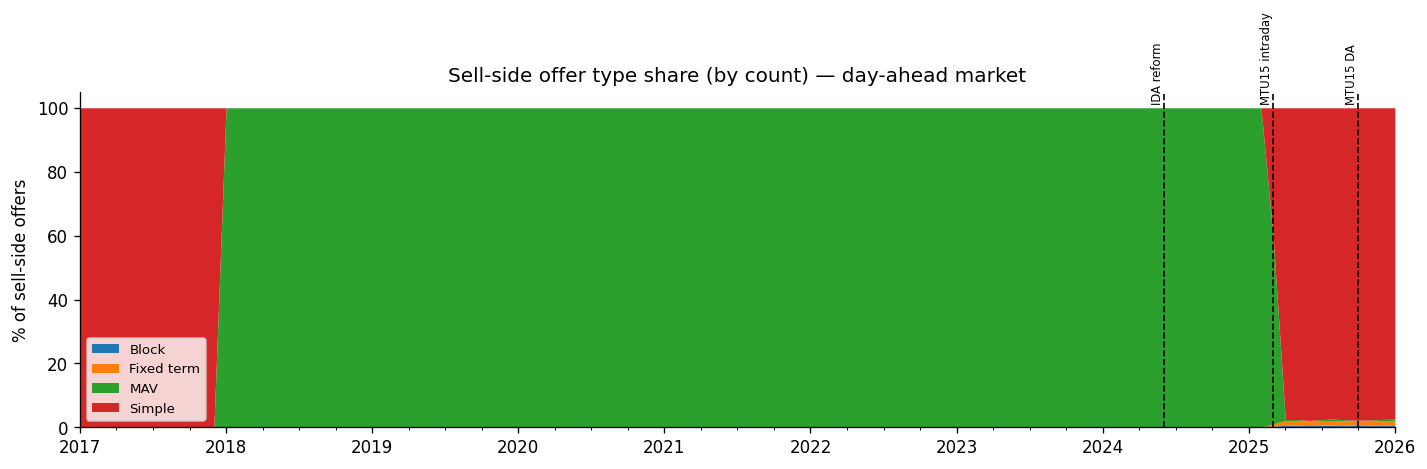

In [3]:
sell = offer_types[offer_types["buy_sell"] == "V"].copy()  # V = venta (sell)
sell["month"] = sell["date"].dt.to_period("M")

monthly_type = (
    sell.groupby(["month", "offer_type"])
    .size()
    .unstack(fill_value=0)
)
monthly_share = monthly_type.div(monthly_type.sum(axis=1), axis=0) * 100
monthly_share.index = monthly_share.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_share.plot.area(ax=ax, linewidth=0)
for d, label in [
    (IDA_REFORM,       "IDA reform"),
    (INTRADAY_REFORM,  "MTU15 intraday"),
    (DAY_AHEAD_REFORM, "MTU15 DA"),
]:
    ax.axvline(d, color="black", lw=1, ls="--")
    ax.text(d, 101, label, rotation=90, va="bottom", ha="right", fontsize=7)
ax.set_ylabel("% of sell-side offers")
ax.set_xlabel("")
ax.set_title("Sell-side offer type share (by count) — day-ahead market")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

### 1b. Offer type share by technology

Conditional distribution of offer types given technology group $\ell$:

$$\phi_{j|\ell} = \frac{\displaystyle\sum_o \mathbf{1}[\text{type}(o) = j,\; \text{tech}(i_o) = \ell]}{\displaystyle\sum_o \mathbf{1}[\text{tech}(i_o) = \ell]}$$

This reveals whether complex conditions (block, MAV) are concentrated in specific technologies.

In [4]:
TECH_MAP = {
    # Solar
    "RE Mercado Solar Fotovoltáica":  "Solar PV",
    "RE Mercado Solar Térmica":       "Solar thermal",
    "RE Tar. CUR Solar Fotovoltáica": "Solar PV",
    "RE Tar. CUR Solar Térmica":      "Solar thermal",
    # Wind
    "RE Mercado Eólica":              "Wind",
    "RE Mercado Eólica Marina":       "Wind",
    "RE Tar. CUR Eólica":             "Wind",
    # Hydro (run-of-river / reservoir)
    "RE Mercado Hidráulica":          "Hydro",
    "Hidráulica Generación":          "Hydro",
    "RE Tar. CUR Hidráulica":         "Hydro",
    # Pumped hydro / demand-side storage
    "Hidráulica de Bombeo Puro":      "Pumped hydro",
    "Consumo Bombeo Mixto":           "Pumped hydro",
    "Consumo Bombeo Puro":            "Pumped hydro",
    "Consumo de bombeo":              "Pumped hydro",
    # Thermal renewable (biomass, biogas, etc.)
    "RE Mercado Térmica Renovable":   "Thermal renew.",
    "RE Tar. CUR Térmica Renovable":  "Thermal renew.",
    # Thermal non-renewable (cogen, waste, etc.)
    "RE Mercado Térmica no Renovab.": "Thermal non-renew.",
    "RE Tar. CUR Térmica no Renov.":  "Thermal non-renew.",
    # Geothermal
    "RE Mercado Geotérmica":          "Geothermal",
    # CCGT
    "Ciclo Combinado":                "CCGT",
    # Coal
    "Carbón de Importación":          "Coal",
    "Hulla Antracita":                "Coal",
    # Gas (non-CCGT)
    "Gas":                            "Gas",
    # Nuclear
    "Nuclear":                        "Nuclear",
    # Battery / storage
    "Almacenamiento Compra":          "Storage",
    "Almacenamiento Venta":           "Storage",
    # Hybrid
    "Híbrida Renovable":              "Hybrid renew.",
    "Híbrida Renov.-Almacenamiento":  "Hybrid renew.",
    "Híbrida Renov.-Térmica":         "Hybrid",
}

units = pd.read_csv(UNITS, sep=",", encoding="utf-8")
# Columns: unit_code, description, owner_agent, ownership_pct, unit_type, zone, technology
print(units.columns.tolist())
units.head(3)

['unit_code', 'description', 'owner_agent', 'ownership_pct', 'unit_type', 'zone', 'technology']


,unit_code,description,owner_agent,ownership_pct,unit_type,zone,technology
0,AFIBGEC,ALMACENAMIENTO COMPRA,IBERDROLA ENERGÍA ESPAÑA S..A.,100.0,ALMACENAMIENTO,ZONA ESPAÑOLA,Almacenamiento Compra
1,AFIBHEC,COMPRA HIBRIDACION EOLICA BAT,IBERDROLA ENERGÍA ESPAÑA S..A.,100.0,ALMACENAMIENTO,ZONA ESPAÑOLA,Almacenamiento Compra
2,AFIBHFC,COMPRA HIBRIDACION FV BATERIA,IBERDROLA ENERGÍA ESPAÑA S..A.,100.0,ALMACENAMIENTO,ZONA ESPAÑOLA,Almacenamiento Compra


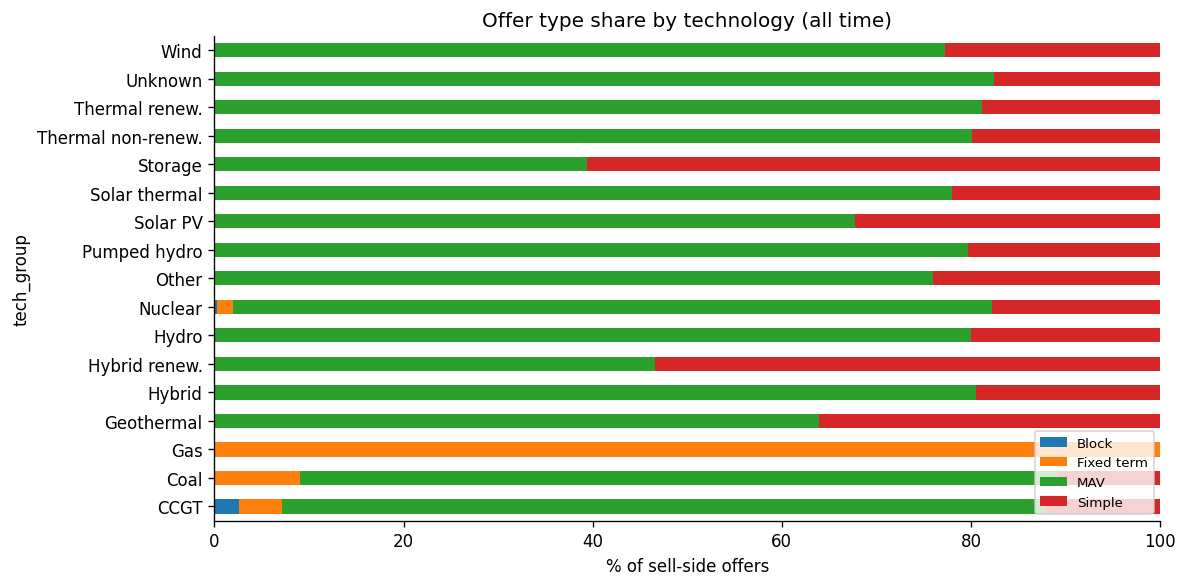

In [5]:
# Adjust column names below once we've seen the actual lista_unidades schema
# Columns: unit_code, description, owner_agent, ownership_pct, unit_type, zone, technology
CODE_COL = "unit_code"       # <- update if different
TECH_COL = "technology"      # <- update if different
AGENT_COL = "owner_agent"     # <- update if different

units["tech_group"] = units[TECH_COL].map(TECH_MAP).fillna("Other")

sell_tech = sell.merge(
    units[[CODE_COL, "tech_group", AGENT_COL]].rename(columns={CODE_COL: "unit_code", AGENT_COL: "owner_agent"}),
    on="unit_code",
    how="left",
)
sell_tech["tech_group"] = sell_tech["tech_group"].fillna("Unknown")

tech_type = (
    sell_tech.groupby(["tech_group", "offer_type"])
    .size()
    .unstack(fill_value=0)
)
tech_share = tech_type.div(tech_type.sum(axis=1), axis=0) * 100

ax = tech_share.plot.barh(stacked=True, figsize=(10, 5))
ax.set_xlabel("% of sell-side offers")
ax.set_title("Offer type share by technology (all time)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### 1c. Block offer usage pre vs post MTU15 intraday reform (2025-03-19)

Post-reform block offer fraction for technology $\ell$:

$$\hat{b}_{\ell} = \frac{\displaystyle\sum_o B_o \cdot \mathbf{1}[t_o \geq t^*,\; \text{tech}(i_o) = \ell]}{\displaystyle\sum_o \mathbf{1}[t_o \geq t^*,\; \text{tech}(i_o) = \ell]}$$

where $t^* = \text{2025-03-19}$. Since $B_o = 0$ for all pre-reform offers by construction, the pre/post comparison is between $\hat{b}_{\ell} = 0$ and the post-reform estimate.

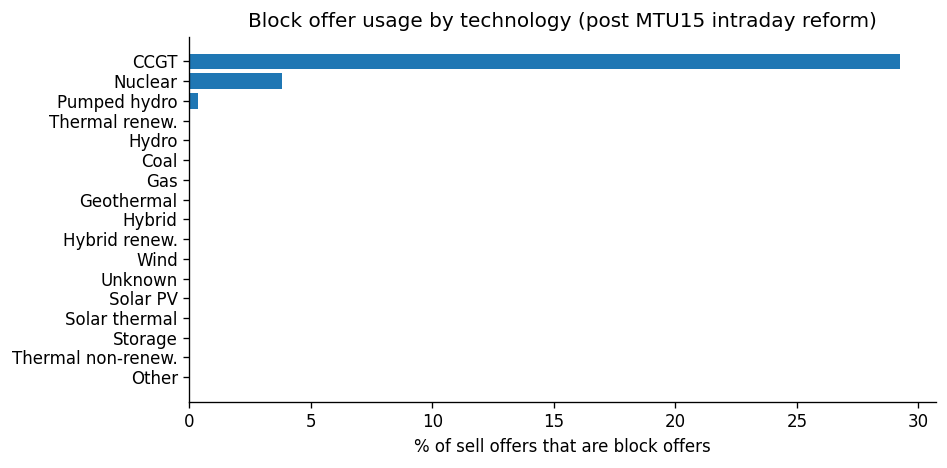

,total,blocks,block_pct
tech_group,,,
Other,13497,0,0.000000
Thermal non-renew.,57809,0,0.000000
Storage,381,0,0.000000
Solar thermal,10414,0,0.000000
Solar PV,282748,0,0.000000
Unknown,48056,0,0.000000
Wind,97302,0,0.000000
Hybrid renew.,2159,0,0.000000
Hybrid,80,0,0.000000


In [6]:
post_reform = sell_tech[sell_tech["date"] >= INTRADAY_REFORM].copy()

block_by_tech = (
    post_reform.groupby("tech_group")["has_block"]
    .agg(total="count", blocks="sum")
    .assign(block_pct=lambda x: x["blocks"] / x["total"] * 100)
    .sort_values("block_pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(block_by_tech.index, block_by_tech["block_pct"])
ax.set_xlabel("% of sell offers that are block offers")
ax.set_title("Block offer usage by technology (post MTU15 intraday reform)")
plt.tight_layout()
plt.show()

block_by_tech

### 1d. Top agents by offer volume and complexity

Rank agents by total sell-side cleared MWh:

$$V_g^{sell} = \tau \sum_{i \in \mathcal{U}_g}\sum_o\sum_h q_{o,h}\cdot\mathbf{1}[\text{buy\_sell}(o) = V]$$

with offer-type breakdown showing $\{V_{g,j}^{sell}\}_j$ to identify agents whose volume comes disproportionately from complex offers.

In [7]:
# Join det for quantities, then aggregate by agent
agent_summary = con.execute(f"""
    WITH det_base AS (
        SELECT
            d.date::DATE AS date,
            d.offer_code,
            d.quantity_mw * (d.mtu_minutes / 60.0) AS qty_mwh,
            MAX(CASE WHEN d.block_number > 0    THEN 1 ELSE 0 END)
                OVER (PARTITION BY d.date, d.offer_code) AS has_block,
            MAX(CASE WHEN d.min_acceptable_volume_mw > 0 THEN 1 ELSE 0 END)
                OVER (PARTITION BY d.date, d.offer_code) AS has_mav
        FROM read_parquet('{DET}') d
        WHERE d.quantity_mw > 0  -- sell side (positive quantities)
    ),
    cab_base AS (
        SELECT date::DATE AS date, offer_code, unit_code,
               CASE WHEN fixed_term_eur IS NOT NULL AND fixed_term_eur <> 0 THEN 1 ELSE 0 END AS has_fixed
        FROM read_parquet('{CAB}')
        WHERE buy_sell = 'V'
    )
    SELECT
        c.unit_code,
        SUM(d.qty_mwh)                                        AS total_mwh,
        SUM(d.qty_mwh * d.has_block)                          AS block_mwh,
        SUM(d.qty_mwh * d.has_mav)                            AS mav_mwh,
        SUM(d.qty_mwh * c.has_fixed)                          AS fixed_mwh,
        SUM(d.qty_mwh * d.has_block)   / SUM(d.qty_mwh) * 100 AS block_pct,
        SUM(d.qty_mwh * d.has_mav)     / SUM(d.qty_mwh) * 100 AS mav_pct,
        SUM(d.qty_mwh * c.has_fixed)   / SUM(d.qty_mwh) * 100 AS fixed_pct
    FROM det_base d
    JOIN cab_base c USING (date, offer_code)
    GROUP BY c.unit_code
    ORDER BY total_mwh DESC
    LIMIT 30
""").df()

agent_summary.head(15)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,unit_code,total_mwh,block_mwh,mav_mwh,fixed_mwh,block_pct,mav_pct,fixed_pct
0,ACAVADO,1.447426e+08,0.0,1.410284e+08,0.0,0.000000,97.433924,0.000000
1,ADOURO,1.200622e+08,0.0,1.133592e+08,0.0,0.000000,94.417047,0.000000
2,DUER,1.047884e+08,0.0,8.888535e+07,0.0,0.000000,84.823683,0.000000
3,TEMON,1.021771e+08,0.0,9.807288e+07,0.0,0.000000,95.983185,0.000000
4,MUEL,1.006231e+08,0.0,9.294254e+07,0.0,0.000000,92.367028,0.000000
5,PEGO3,9.765950e+07,108079.2,9.677786e+07,1856144.8,0.110669,99.097231,1.900629
6,PEGO4,9.649124e+07,261780.0,9.489575e+07,1245188.6,0.271299,98.346500,1.290468
7,BES5,9.532618e+07,1513988.0,9.335115e+07,1604940.0,1.588219,97.928137,1.683630
8,PGR5,9.307209e+07,3188204.2,8.930893e+07,1067477.2,3.425521,95.956718,1.146936
9,ALIMA,8.627058e+07,0.0,7.511751e+07,0.0,0.000000,87.071984,0.000000


### 1e. Agent classification: sell-side, buy-side, and mixed

Define the sell share of agent $g$ from day-ahead matched volumes in `det`:

$$\rho_g = \frac{V_g^{sell}}{V_g^{sell} + V_g^{buy}}$$

where $V_g^{buy} = \tau\sum_{i\in\mathcal{U}_g}\sum_o\sum_h q_{o,h}\cdot\mathbf{1}[\text{buy\_sell}(o) = C]$. Classification:

$$\text{group}(g) = \begin{cases} \text{Mostly sell} & \rho_g \geq 0.8 \\[2pt] \text{Mixed} & 0.2 \leq \rho_g < 0.8 \\[2pt] \text{Mostly buy} & \rho_g < 0.2 \end{cases}$$

Mixed agents ($0.2 \leq \rho_g < 0.8$) are the strategically interesting group: they simultaneously hold generation and retail positions and can arbitrage across markets.

In [8]:
agent_balance = con.execute(f"""
    WITH det_cab AS (
        SELECT
            d.date::DATE AS date,
            d.quantity_mw,
            d.mtu_minutes,
            c.buy_sell,
            c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
            ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE d.quantity_mw IS NOT NULL
    ),
    with_agent AS (
        SELECT
            dc.date,
            dc.buy_sell,
            ABS(dc.quantity_mw) * dc.mtu_minutes / 60.0 AS mwh,
            COALESCE(u.owner_agent, 'Unknown')           AS agent,
            COALESCE(u.technology,  'Unknown')           AS technology
        FROM det_cab dc
        LEFT JOIN read_csv('{UNITS}', delim=',', header=true) u
            ON dc.unit_code = u.unit_code
    )
    SELECT
        agent,
        technology,
        SUM(CASE WHEN buy_sell = 'V' THEN mwh ELSE 0 END) AS sell_mwh,
        SUM(CASE WHEN buy_sell = 'C' THEN mwh ELSE 0 END) AS buy_mwh,
        SUM(mwh)                                           AS total_mwh
    FROM with_agent
    GROUP BY agent, technology
    ORDER BY total_mwh DESC
""").df()

# Pivot to agent level
agent_agg = (
    agent_balance
    .groupby("agent")[["sell_mwh", "buy_mwh", "total_mwh"]]
    .sum()
    .reset_index()
)
agent_agg["sell_pct"] = agent_agg["sell_mwh"] / agent_agg["total_mwh"]

# Classify
def classify(p):
    if p >= 0.80:
        return "Mostly sell"
    elif p <= 0.20:
        return "Mostly buy"
    else:
        return "Mixed"

agent_agg["group"] = agent_agg["sell_pct"].apply(classify)

print(agent_agg["group"].value_counts())
print()
print(agent_agg.sort_values("total_mwh", ascending=False).head(20)[
    ["agent", "sell_mwh", "buy_mwh", "total_mwh", "sell_pct", "group"]
].to_string())

group
Mostly buy     370
Mostly sell     47
Mixed           25
Name: count, dtype: int64

                                    agent      sell_mwh       buy_mwh     total_mwh  sell_pct        group
420                               Unknown  9.595697e+08  1.478496e+09  2.438065e+09  0.393578        Mixed
248        IBERDROLA ENERGÍA ESPAÑA S..A.  1.157346e+09  1.689448e+08  1.326290e+09  0.872619  Mostly sell
212          GAS NATURAL COMERCIALIZADORA  1.161814e+09  5.896150e+07  1.220775e+09  0.951702  Mostly sell
145               ENDESA GENERACIÓN, S.A.  9.112451e+08  1.433061e+07  9.255757e+08  0.984517  Mostly sell
118                 EDP GEM PORTUGAL S.A.  8.340913e+08  8.183473e+07  9.159260e+08  0.910654  Mostly sell
253                    IGNIS ENERGIA S.L.  2.753515e+08  3.493147e+07  3.102830e+08  0.887421  Mostly sell
219                      GESTERNOVA, S.A.  2.466207e+08  0.000000e+00  2.466207e+08  1.000000  Mostly sell
117       EDP ESPAÑA, S.A.U. (GENERACIÓN)  2.050079e+0

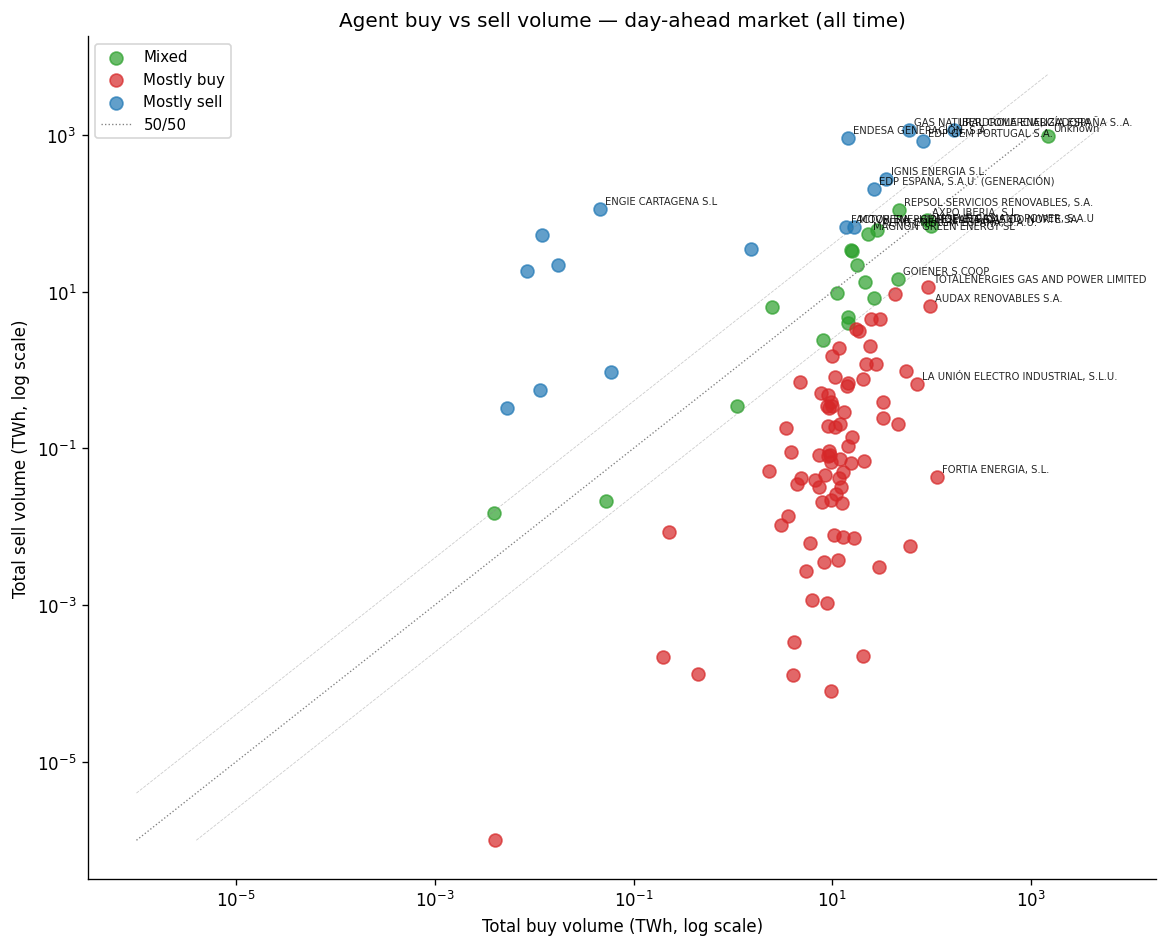

In [9]:
# Scatter: sell vs buy volume per agent, coloured by group (log scale)
import numpy as np

colors = {"Mostly sell": "C0", "Mixed": "C2", "Mostly buy": "C3"}

# Exclude agents with zero on either axis (log needs > 0)
plot_df = agent_agg[(agent_agg["buy_mwh"] > 0) & (agent_agg["sell_mwh"] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 8))

for grp, sub in plot_df.groupby("group"):
    ax.scatter(
        sub["buy_mwh"] / 1e6,
        sub["sell_mwh"] / 1e6,
        label=grp,
        alpha=0.7,
        s=60,
        color=colors[grp],
    )

# Label top agents (by total volume) that appear in the plot
top = agent_agg.nlargest(25, "total_mwh")
top = top[(top["buy_mwh"] > 0) & (top["sell_mwh"] > 0)]
for _, row in top.iterrows():
    ax.annotate(
        row["agent"],
        (row["buy_mwh"] / 1e6, row["sell_mwh"] / 1e6),
        fontsize=6,
        alpha=0.85,
        xytext=(3, 3),
        textcoords="offset points",
    )

# Log scale
ax.set_xscale("log")
ax.set_yscale("log")

# Diagonal reference lines in log space
lo = min(plot_df["buy_mwh"].min(), plot_df["sell_mwh"].min()) / 1e6
hi = max(plot_df["buy_mwh"].max(), plot_df["sell_mwh"].max()) / 1e6
ref = np.geomspace(lo, hi, 200)
ax.plot(ref, ref,       color="grey", lw=0.8, ls=":",  label="50/50")
ax.plot(ref, ref * 4,   color="grey", lw=0.5, ls="--", alpha=0.4)
ax.plot(ref * 4, ref,   color="grey", lw=0.5, ls="--", alpha=0.4)

ax.set_xlabel("Total buy volume (TWh, log scale)")
ax.set_ylabel("Total sell volume (TWh, log scale)")
ax.set_title("Agent buy vs sell volume — day-ahead market (all time)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


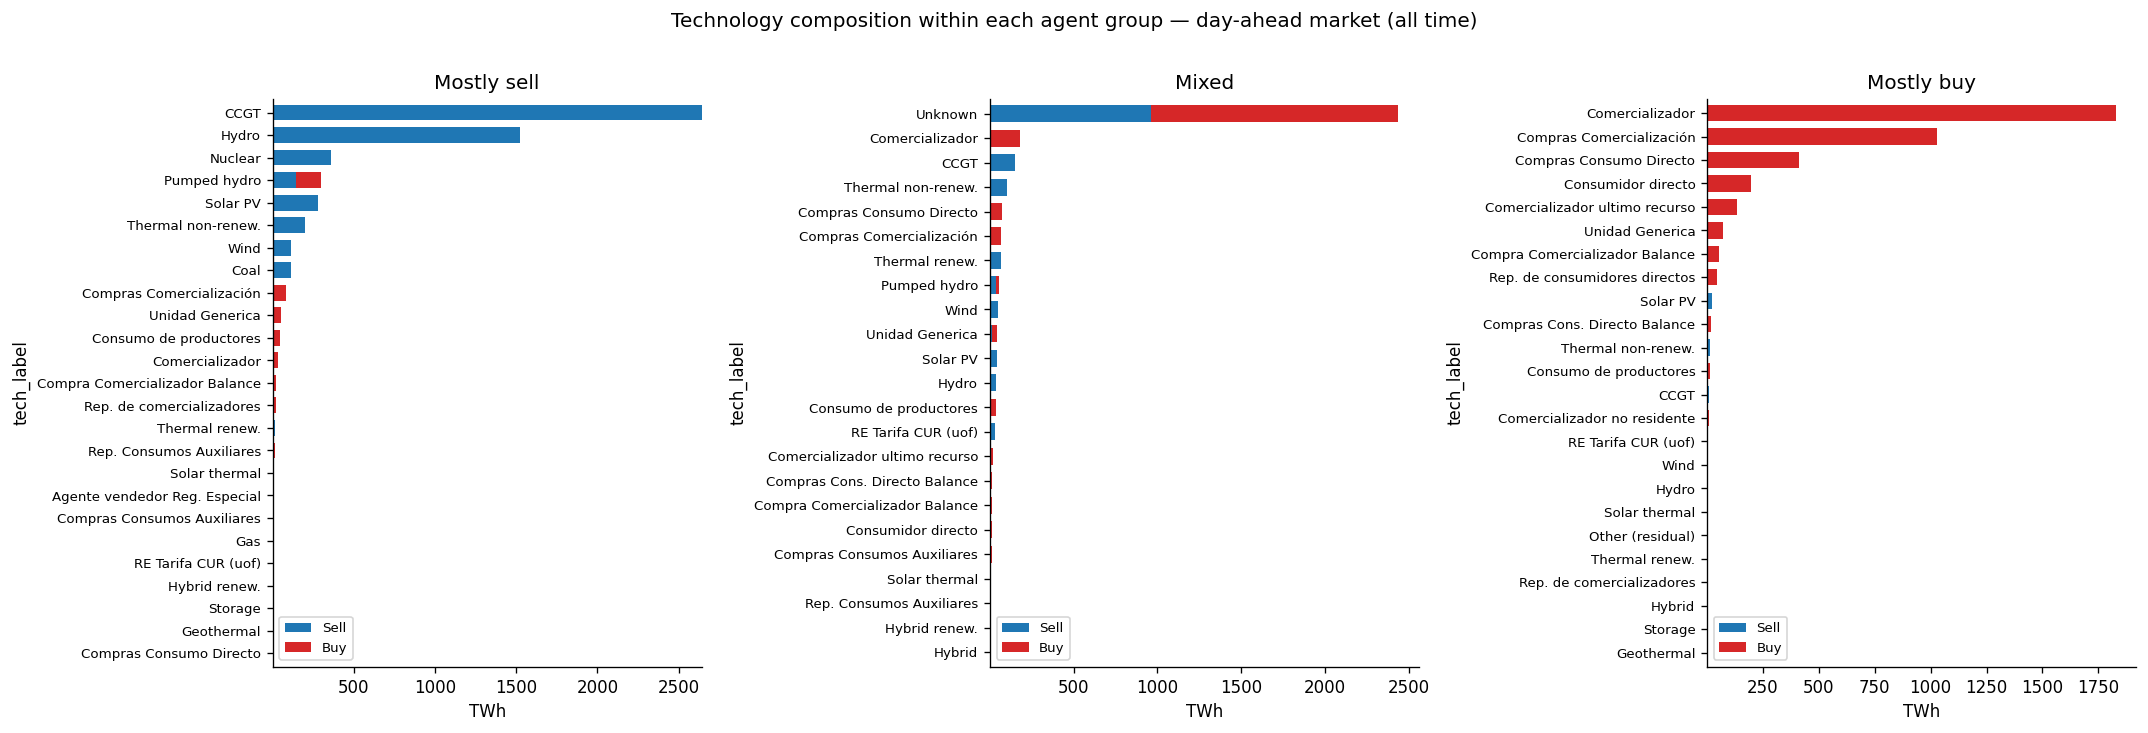

In [10]:
# Technology breakdown within each group
# Map technology strings to groups using TECH_MAP; keep all meaningful categories

agent_tech = agent_balance.copy()
agent_tech["tech_group"] = agent_tech["technology"].map(TECH_MAP)

# For unmapped technologies, keep the original string if it has enough volume,
# otherwise label "Other (residual)"
RESIDUAL_THRESHOLD_MWH = 5e5  # 500 GWh total across all time — below this → residual
tech_totals = agent_tech.groupby("technology")["total_mwh"].sum()
residual_techs = set(tech_totals[tech_totals < RESIDUAL_THRESHOLD_MWH].index)

def map_tech(row):
    if row["tech_group"] is not None and not (isinstance(row["tech_group"], float)):
        return row["tech_group"]
    if row["technology"] in residual_techs:
        return "Other (residual)"
    return row["technology"]   # keep the raw label — it's meaningful volume

agent_tech["tech_label"] = agent_tech.apply(map_tech, axis=1)

# Merge group classification back
agent_tech = agent_tech.merge(agent_agg[["agent", "group"]], on="agent", how="left")
agent_tech["group"] = agent_tech["group"].fillna("Mixed")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, grp in zip(axes, ["Mostly sell", "Mixed", "Mostly buy"]):
    sub = agent_tech[agent_tech["group"] == grp]
    by_tech = (
        sub.groupby("tech_label")[["sell_mwh", "buy_mwh"]]
        .sum()
        .assign(total=lambda x: x["sell_mwh"] + x["buy_mwh"])
        .sort_values("total", ascending=True)
    )
    by_tech[["sell_mwh", "buy_mwh"]].div(1e6).plot.barh(
        ax=ax, stacked=True, color=["C0", "C3"], width=0.7
    )
    ax.set_title(f"{grp}")
    ax.set_xlabel("TWh")
    ax.legend(["Sell", "Buy"], fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Technology composition within each agent group — day-ahead market (all time)", y=1.01)
plt.tight_layout()
plt.show()

---
## Section 1b — Intraday auction offer anatomy (icab + idet)

Same analysis as Section 1 but for the **intraday auctions** (IDAS).

Each intraday auction offer is indexed by the triple $(t, s, \text{offer\_code})$ in `icab`. The same triple links to matched period-level detail in `idet`. Unlike the day-ahead, the offer category is encoded entirely in the `need_type` field — there is no separate complex-offer structure.

Two format regimes in `icab`:
- **Pre-IDA-reform (before 2024-06-14)**: 195-char lines, `need_type` codes `N 1`, `N 5`, `N 7`, etc.
- **Post-IDA-reform (2024-06-14+)**: 94-char lines, `need_type` codes `120`, `130`, `50`, `70`, etc.; Block Order fields active.

**Five offer-type categories** derived from `need_type` and block fields:

| Category | Pre-IDA codes | Post-IDA codes | Who |
|---|---|---|---|
| **Simple** | `N 1` (no block) | `120`, `130` (no block) | Standard generators / consumers / traders |
| **Block Order** | — | `120`, `130` + block fields | Simple Block Orders (EUPHEMIA); post-IDA only |
| **RE sell-side** | `N 7` | `70`, `113` | Dedicated RE sell-side via aggregators |
| **Commercial agg.** | `N 5` | `50`, `111` | Mixed buy/sell aggregators; shifted net-buy post-IDA |
| **RE consumer** | `N 6`, `N 8`, `N 9` | `61`, `81`, `90`, `101`–`103` | Direct consumers and demand-response |

**Block Order indicator** (post-IDA only):

$$B_o^{IDA} = \mathbf{1}[\text{block\_order\_avg\_price\_eur}_o \neq 0 \text{ and not null}]$$

This is distinct from `block_number` in `idet`, which indexes supply-curve tranches and is always $\geq 1$ for matched offers regardless of offer type.

In [11]:
ICAB = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/ofertas/icab_all.parquet"
IDET = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/ofertas/idet_all.parquet"

# Five offer-type categories derived from need_type and block fields:
#   RE sell-side        — N 7 / 70 / 113: dedicated RE sell-side generators
#   Commercial agg.     — N 5 / 50 / 111: mixed buy/sell aggregators
#   RE consumer         — N 6 / 61 / N 8 / 81 / 90 / 101-103 / N 9: direct consumers
#   Block Order         — standard need_type WITH block_order_avg_price_eur != 0
#   Simple              — standard need_type without block conditions
ida_offer_types = con.execute(f"""
    WITH idet_agg AS (
        SELECT
            date,
            session_number,
            offer_code,
            MAX(CASE WHEN block_number > 0 THEN 1 ELSE 0 END) AS has_block,
            SUM(ABS(quantity_mw) * mtu_minutes / 60.0)        AS qty_mwh
        FROM read_parquet('{IDET}')
        GROUP BY date, session_number, offer_code
    )
    SELECT
        c.date::DATE                                                AS date,
        c.session_number,
        c.offer_code,
        c.unit_code,
        c.buy_sell,
        c.need_type,
        COALESCE(d.has_block, 0)                                    AS has_block,
        CASE
            WHEN c.block_order_avg_price_eur IS NOT NULL
             AND c.block_order_avg_price_eur <> 0 THEN 1 ELSE 0
        END                                                         AS has_block_order,
        CASE
            WHEN c.block_order_min_pct IS NOT NULL
             AND c.block_order_min_pct > 0 THEN 1 ELSE 0
        END                                                         AS has_min_pct,
        COALESCE(d.qty_mwh, 0)                                      AS qty_mwh,
        CASE
            WHEN c.need_type IN ('N 7', '70', '113')              THEN 'RE sell-side'
            WHEN c.need_type IN ('N 5', '50', '111')              THEN 'Commercial agg.'
            WHEN c.need_type IN ('N 6', '61', 'N 8', '81',
                                 '90', '101', '102', '103', 'N 9') THEN 'RE consumer'
            WHEN (c.block_order_avg_price_eur IS NOT NULL
                  AND c.block_order_avg_price_eur <> 0)             THEN 'Block Order'
            ELSE 'Simple'
        END                                                         AS offer_type
    FROM read_parquet('{ICAB}') c
    LEFT JOIN idet_agg d USING (date, session_number, offer_code)
""").df()

ida_offer_types["date"] = pd.to_datetime(ida_offer_types["date"])
print(f"Rows: {len(ida_offer_types):,}")
ida_offer_types[["offer_type", "buy_sell"]].value_counts().head(12)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 17,706,357


offer_type       buy_sell
Simple           V           12744992
                 C            3171364
RE sell-side     V             633984
Commercial agg.  V             551880
                 C             439857
RE sell-side     C              79631
RE consumer      C              58717
Block Order      C              13847
                 V               9355
RE consumer      V               2730
Name: count, dtype: int64

### 1b-a. Offer type share over time (sell side, intraday auctions)

Monthly sell-side offer type share pooled across sessions:

$$\phi_{\tau,j}^{IDA} = \frac{\displaystyle\sum_{t\in\tau}\sum_s N_{t,s,j}^{IDA,sell}}{\displaystyle\sum_{t\in\tau}\sum_s N_{t,s}^{IDA,sell}}$$

Note the structural break at the IDA reform ($t^{IDA} = \text{2024-06-14}$): $\phi_{\tau,\text{RE sell-side}}^{IDA}$ approximately doubles while $\phi_{\tau,\text{Commercial agg.}}^{IDA}$ collapses — aggregators shifted to net-buy after European IDA coupling.

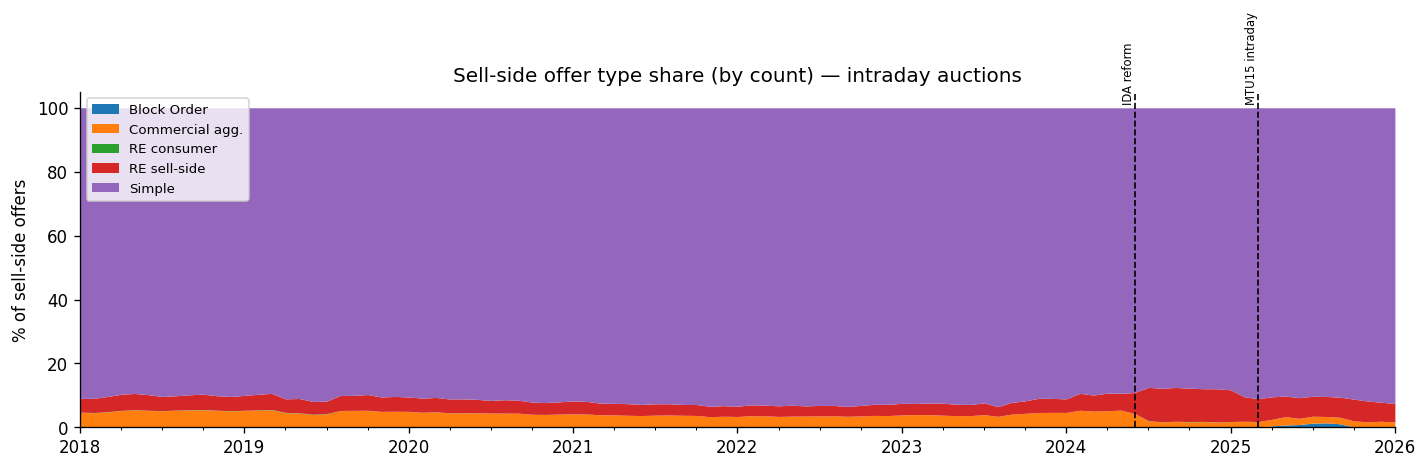

In [12]:
sell_ida = ida_offer_types[ida_offer_types["buy_sell"] == "V"].copy()
sell_ida["month"] = sell_ida["date"].dt.to_period("M")

monthly_ida = (
    sell_ida.groupby(["month", "offer_type"])
    .size()
    .unstack(fill_value=0)
)
monthly_ida_share = monthly_ida.div(monthly_ida.sum(axis=1), axis=0) * 100
monthly_ida_share.index = monthly_ida_share.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_ida_share.plot.area(ax=ax, linewidth=0)
for d, label in [
    (IDA_REFORM,       "IDA reform"),
    (INTRADAY_REFORM,  "MTU15 intraday"),
]:
    ax.axvline(d, color="black", lw=1, ls="--")
    ax.text(d, 101, label, rotation=90, va="bottom", ha="right", fontsize=7)
ax.set_ylabel("% of sell-side offers")
ax.set_xlabel("")
ax.set_title("Sell-side offer type share (by count) — intraday auctions")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 1b-b. Block offer usage by session number

Block Order fraction per session $s$:

$$b_s = \frac{\displaystyle\sum_{t,o} B_o^{IDA}\cdot\mathbf{1}[s_o = s]}{\displaystyle\sum_{t,o} \mathbf{1}[s_o = s]}$$

By construction $b_s = 0$ for all pre-IDA-reform sessions (block fields not populated in 195-char format). Post-IDA, $b_s$ captures whether earlier sessions (closer to delivery) use Block Orders differently from later ones — earlier sessions face more uncertain residual demand.

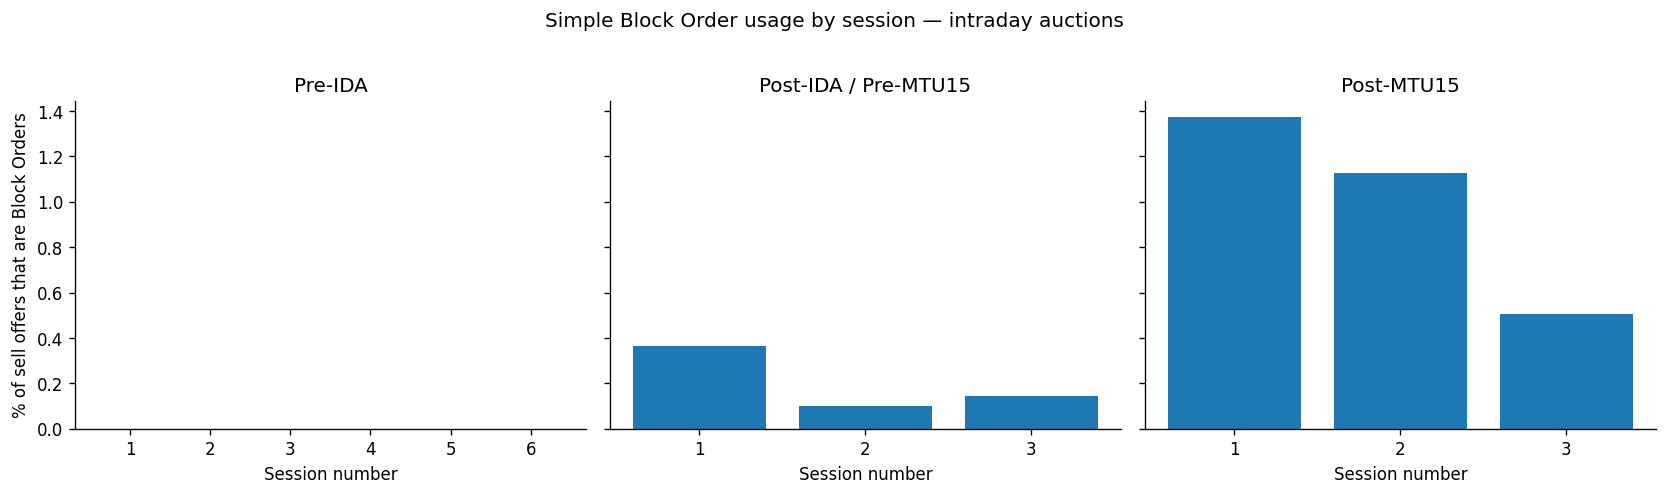

regime,Post-IDA / Pre-MTU15,Post-MTU15,Pre-IDA
session_number,,,
1,0.4,1.4,0.0
2,0.1,1.1,0.0
3,0.1,0.5,0.0
4,NaN,NaN,0.0
5,NaN,NaN,0.0
6,NaN,NaN,0.0


In [13]:
sell_ida["regime"] = "Pre-IDA"
sell_ida.loc[sell_ida["date"] >= IDA_REFORM,       "regime"] = "Post-IDA / Pre-MTU15"
sell_ida.loc[sell_ida["date"] >= INTRADAY_REFORM,  "regime"] = "Post-MTU15"

# Use has_block_order (icab field: block_order_avg_price_eur != 0) as the block indicator.
# block_number in idet is a tranche number (always ≥1), not a block order flag.
# Simple Block Orders only exist post-IDA reform (2024-06-14+).
session_block = (
    sell_ida.groupby(["regime", "session_number"])["has_block_order"]
    .agg(total="count", blocks="sum")
    .assign(block_pct=lambda x: x["blocks"] / x["total"] * 100)
    .reset_index()
)

regimes = ["Pre-IDA", "Post-IDA / Pre-MTU15", "Post-MTU15"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, regime in zip(axes, regimes):
    sub = session_block[session_block["regime"] == regime].sort_values("session_number")
    ax.bar(sub["session_number"].astype(str), sub["block_pct"])
    ax.set_title(regime)
    ax.set_xlabel("Session number")
    if ax is axes[0]:
        ax.set_ylabel("% of sell offers that are Block Orders")

plt.suptitle("Simple Block Order usage by session — intraday auctions", y=1.02)
plt.tight_layout()
plt.show()

session_block.pivot(index="session_number", columns="regime", values="block_pct").round(1)


### 1b-c. Agent classification — intraday auctions

Define the intraday auction sell share of agent $g$:

$$\rho_g^{IDA} = \frac{V_g^{IDA,sell}}{V_g^{IDA,sell} + V_g^{IDA,buy}}$$

where $V_g^{IDA,sell} = \tau\sum_{i\in\mathcal{U}_g}\sum_{t,s,h,k} q_{ithsk}\cdot\mathbf{1}[\text{buy\_sell} = V]$ (from `idet`). The classification thresholds are the same as Section 1e ($\rho \geq 0.8$ sell, $\leq 0.2$ buy, otherwise mixed). Pre-aggregate `idet` to offer level before joining `icab` to keep the query tractable.

In [14]:
agent_balance_ida = con.execute(f"""
    WITH idet_offer AS (
        SELECT
            date, session_number, offer_code,
            SUM(ABS(quantity_mw) * mtu_minutes / 60.0) AS mwh
        FROM read_parquet('{IDET}')
        WHERE quantity_mw IS NOT NULL
        GROUP BY date, session_number, offer_code
    )
    SELECT
        COALESCE(u.owner_agent, c.unit_code) AS agent,
        COALESCE(u.technology, 'Unknown')    AS technology,
        SUM(CASE WHEN c.buy_sell = 'V' THEN d.mwh ELSE 0 END) AS sell_mwh,
        SUM(CASE WHEN c.buy_sell = 'C' THEN d.mwh ELSE 0 END) AS buy_mwh,
        SUM(d.mwh)                                             AS total_mwh
    FROM idet_offer d
    JOIN read_parquet('{ICAB}') c
        USING (date, session_number, offer_code)
    LEFT JOIN read_csv('{UNITS}', delim=',', header=true) u
        ON c.unit_code = u.unit_code
    GROUP BY agent, technology
    ORDER BY total_mwh DESC
""").df()

agent_agg_ida = (
    agent_balance_ida
    .groupby("agent")[["sell_mwh", "buy_mwh", "total_mwh"]]
    .sum()
    .reset_index()
)
agent_agg_ida["sell_pct"] = agent_agg_ida["sell_mwh"] / agent_agg_ida["total_mwh"]
agent_agg_ida["group"]    = agent_agg_ida["sell_pct"].apply(classify)

print(agent_agg_ida["group"].value_counts())
print()
agent_agg_ida.sort_values("total_mwh", ascending=False).head(15)[
    ["agent", "sell_mwh", "buy_mwh", "total_mwh", "sell_pct", "group"]
].round(0)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

group
Mostly sell    1039
Mostly buy      654
Mixed           257
Name: count, dtype: int64



,agent,sell_mwh,buy_mwh,total_mwh,sell_pct,group
1199,IBERDROLA ENERGÍA ESPAÑA S..A.,783311867.0,363507389.0,1.146819e+09,1.0,Mixed
529,EDP GEM PORTUGAL S.A.,526008763.0,327192481.0,8.532012e+08,1.0,Mixed
939,GAS NATURAL COMERCIALIZADORA,421875628.0,41423800.0,4.632994e+08,1.0,Mostly sell
1641,"REPSOL SERVICIOS RENOVABLES, S.A.",121486960.0,60014914.0,1.815019e+08,1.0,Mixed
753,"ENDESA GENERACIÓN, S.A.",153566307.0,13544435.0,1.671107e+08,1.0,Mostly sell
976,"GESTERNOVA, S.A.",87903577.0,2847336.0,9.075091e+07,1.0,Mostly sell
975,"GESTERNOVA, S.A",1948497.0,86593825.0,8.854232e+07,0.0,Mostly buy
761,ENEL GREEN POWER ESPAÑA SL (ACT: COM RE),57855268.0,20249419.0,7.810469e+07,1.0,Mixed
92,"AXPO IBERIA, S.L.",40351501.0,12341132.0,5.269263e+07,1.0,Mixed
1407,MOVHERA - HIDROELÉTRICAS DO NORTE SA,26745917.0,11307452.0,3.805337e+07,1.0,Mixed


### 1b-d. Agent buy vs sell volume — intraday auctions (log scale)

Scatter of $(V_g^{IDA,sell}, V_g^{IDA,buy})$ on a log–log scale, coloured by group. Agents on the diagonal ($V_g^{sell} \approx V_g^{buy}$) are balanced portfolio traders; agents far above or below the diagonal are net generators or net consumers.

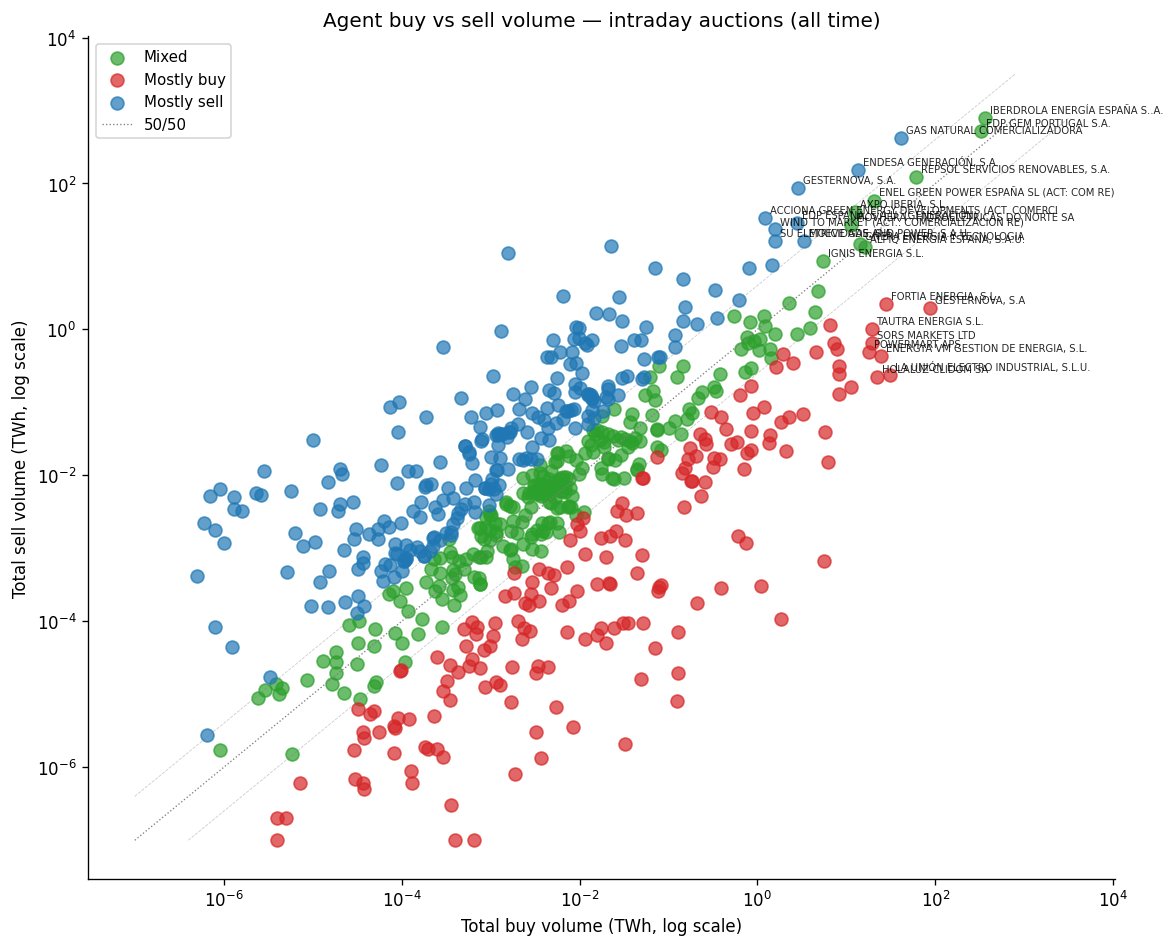

In [15]:
colors_ida = {"Mostly sell": "C0", "Mixed": "C2", "Mostly buy": "C3"}

plot_df_ida = agent_agg_ida[
    (agent_agg_ida["buy_mwh"] > 0) & (agent_agg_ida["sell_mwh"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(10, 8))

for grp, sub in plot_df_ida.groupby("group"):
    ax.scatter(
        sub["buy_mwh"] / 1e6,
        sub["sell_mwh"] / 1e6,
        label=grp,
        alpha=0.7,
        s=60,
        color=colors_ida[grp],
    )

top_ida = agent_agg_ida.nlargest(25, "total_mwh")
top_ida = top_ida[(top_ida["buy_mwh"] > 0) & (top_ida["sell_mwh"] > 0)]
for _, row in top_ida.iterrows():
    ax.annotate(
        row["agent"],
        (row["buy_mwh"] / 1e6, row["sell_mwh"] / 1e6),
        fontsize=6, alpha=0.85, xytext=(3, 3), textcoords="offset points",
    )

ax.set_xscale("log")
ax.set_yscale("log")

lo = min(plot_df_ida["buy_mwh"].min(), plot_df_ida["sell_mwh"].min()) / 1e6
hi = max(plot_df_ida["buy_mwh"].max(), plot_df_ida["sell_mwh"].max()) / 1e6
ref = np.geomspace(lo, hi, 200)
ax.plot(ref, ref,     color="grey", lw=0.8, ls=":",  label="50/50")
ax.plot(ref, ref * 4, color="grey", lw=0.5, ls="--", alpha=0.4)
ax.plot(ref * 4, ref, color="grey", lw=0.5, ls="--", alpha=0.4)

ax.set_xlabel("Total buy volume (TWh, log scale)")
ax.set_ylabel("Total sell volume (TWh, log scale)")
ax.set_title("Agent buy vs sell volume — intraday auctions (all time)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 1b-e. Cross-market comparison: day-ahead group vs intraday auction group

For agents active in both markets, compare $\text{group}_{DA}(g) = f(\rho_g)$ with $\text{group}_{IDA}(g) = f(\rho_g^{IDA})$. Agents who are "Mostly sell" in the day-ahead but "Mixed" in the intraday are likely using intraday auctions to hedge production uncertainty — buying back positions they cannot deliver.

In [16]:
cross = (
    agent_agg[["agent", "group", "total_mwh"]]
    .rename(columns={"group": "da_group", "total_mwh": "da_mwh"})
    .merge(
        agent_agg_ida[["agent", "group", "total_mwh"]]
        .rename(columns={"group": "ida_group", "total_mwh": "ida_mwh"}),
        on="agent",
        how="inner",
    )
)

print(f"Agents active in both markets: {len(cross)}")
print()

# Crosstab of DA group → IDA group
crosstab = pd.crosstab(cross["da_group"], cross["ida_group"], margins=True)
print("Agent group transition: day-ahead → intraday auctions")
display(crosstab)

# Volume-weighted: which DA group puts most volume into intraday?
vol_cross = (
    cross.groupby(["da_group", "ida_group"])
    .agg(n_agents=("agent", "count"), ida_twh=("ida_mwh", "sum"))
    .assign(ida_twh=lambda x: x["ida_twh"] / 1e6)
    .reset_index()
)
vol_piv = vol_cross.pivot(index="da_group", columns="ida_group", values="ida_twh").fillna(0).round(1)
print()
print("Intraday auction volume (TWh) by DA group → IDA group:")
display(vol_piv)

Agents active in both markets: 390

Agent group transition: day-ahead → intraday auctions


ida_group,Mixed,Mostly buy,Mostly sell,All
da_group,,,,
Mixed,9,5,8,22
Mostly buy,79,234,9,322
Mostly sell,13,1,32,46
All,101,240,49,390



Intraday auction volume (TWh) by DA group → IDA group:


ida_group,Mixed,Mostly buy,Mostly sell
da_group,,,
Mixed,354.2,10.5,40.7
Mostly buy,46.5,344.3,0.6
Mostly sell,2082.2,0.1,856.8


---
## Section 2 — Day-ahead ↔ intraday price spread & arbitrage

**Markets compared:**
- Day-ahead (`marginalpdbc`): clears $\approx D{-}1$, produces $p^{DA}_{th}$
- Intraday auctions (`marginalpibc`): produces $p^{IDA}_{ths}$ per session $s$
- Intraday continuous (`precios_pibcic_ronda`): produces $p^{CONT}_{thr}$ per round $r$

**Spread definition.** For matched periods, the intraday auction spread is

$$\text{spread}_{ths} = p^{IDA}_{ths} - p^{DA}_{th}$$

and the continuous spread is $\text{spread}^{cont}_{thr} = p^{CONT}_{thr} - p^{DA}_{th}$.

**Period alignment.** Pre-MTU15, both markets have 25-period (hourly) resolution. Post-MTU15, `marginalpibc` has 100 quarter-hourly periods; `marginalpdbc` remains hourly until 2025-10-01. Spread comparison across regimes requires careful period mapping.

### 2a. Day-ahead vs intraday auction spread over time

Monthly mean absolute spread between DA and IDA session $s$:

$$\overline{|\text{spread}|}_{\tau,s} = \frac{1}{|\mathcal{T}_\tau||\mathcal{H}|} \sum_{t\in\tau}\sum_h \left|p^{IDA}_{ths} - p^{DA}_{th}\right|$$

A persistent non-zero spread indicates either systematic risk premia (generators demand a premium for last-minute supply) or structural price formation differences between the two auctions. Efficient markets would predict $\mathbb{E}[\text{spread}_{ths}] \approx 0$, with deviations explained by residual demand uncertainty.

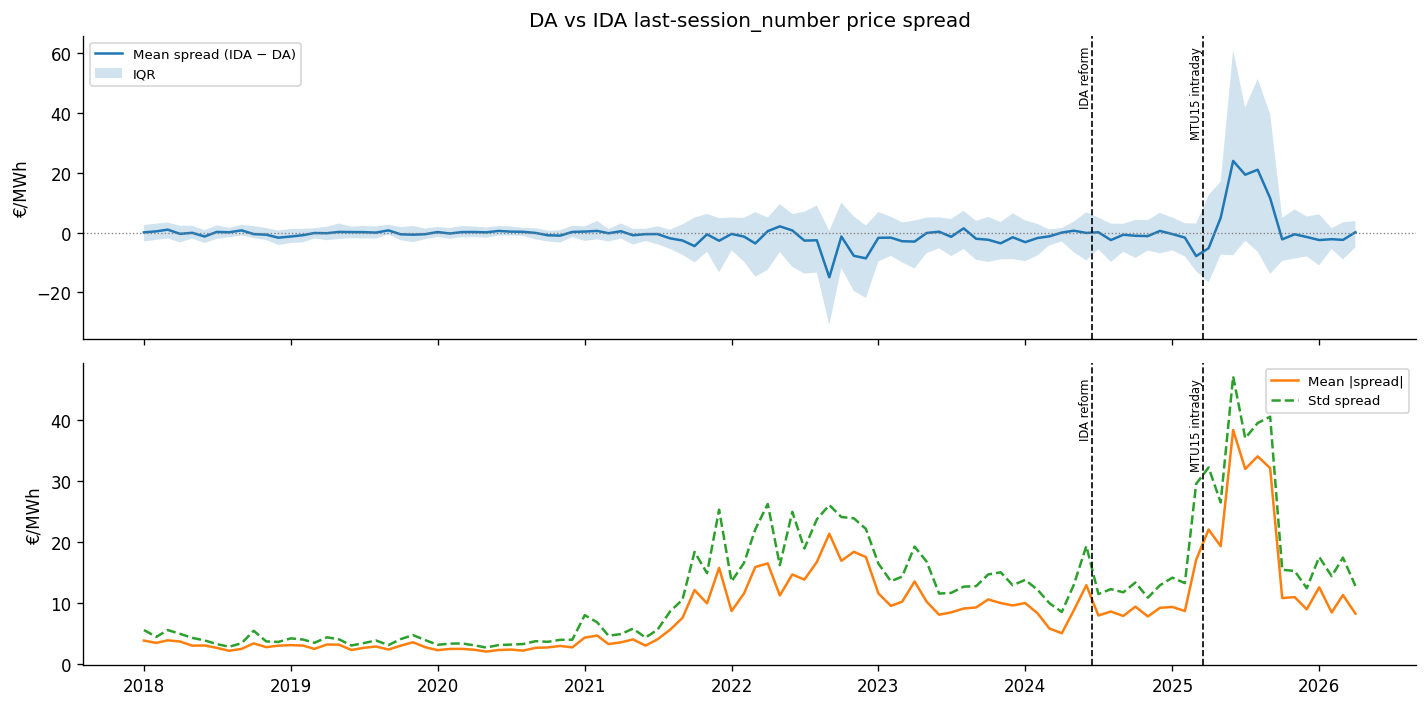

In [17]:
# Note: marginalpibc has one row per (date, session_number, period).
# We align on delivery date + period. Post-IDA reform: session_number 1 = IDA1 (D-1 evening).
# We use session_number with the latest gate closure (highest session_number number) as "final intraday price".

spread_ida = con.execute(f"""
    WITH da AS (
        SELECT date::DATE AS date, period, price_es_eur_mwh AS da_price
        FROM read_parquet('{MARGINALPDBC}')
    ),
    ida_last AS (
        -- Take the last session_number available for each (date, period)
        SELECT date::DATE AS date, period,
               price_es_eur_mwh AS ida_price,
               ROW_NUMBER() OVER (PARTITION BY date::DATE, period ORDER BY session_number DESC) AS rn
        FROM read_parquet('{MARGINALPIBC}')
    ),
    joined AS (
        SELECT
            da.date,
            da.period,
            da.da_price,
            ida.ida_price,
            (ida.ida_price - da.da_price) AS spread
        FROM da
        JOIN ida_last ida USING (date, period)
        WHERE ida.rn = 1
    )
    SELECT
        DATE_TRUNC('month', date) AS month,
        AVG(spread)               AS mean_spread,
        AVG(ABS(spread))          AS mean_abs_spread,
        STDDEV(spread)            AS std_spread,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY spread) AS p25,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY spread) AS p75
    FROM joined
    GROUP BY 1
    ORDER BY 1
""").df()

spread_ida["month"] = pd.to_datetime(spread_ida["month"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(spread_ida["month"], spread_ida["mean_spread"], label="Mean spread (IDA − DA)", lw=1.5)
ax.fill_between(spread_ida["month"], spread_ida["p25"], spread_ida["p75"], alpha=0.2, label="IQR")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_ylabel("€/MWh")
ax.set_title("DA vs IDA last-session_number price spread")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(spread_ida["month"], spread_ida["mean_abs_spread"], color="C1", lw=1.5, label="Mean |spread|")
ax.plot(spread_ida["month"], spread_ida["std_spread"],      color="C2", lw=1.5, ls="--", label="Std spread")
ax.set_ylabel("€/MWh")
ax.legend(fontsize=8)

for ax in axes:
    for d, label in [
        (IDA_REFORM,       "IDA reform"),
        (INTRADAY_REFORM,  "MTU15 intraday"),
    ]:
        ax.axvline(d, color="black", lw=1, ls="--")
        ax.text(d, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=7)

plt.tight_layout()
plt.show()

### 2b. Intra-hour spread: does MTU15 reveal within-hour price dispersion?

Post-MTU15 (2025-03-19+), each hourly slot $\hat{h}$ contains four 15-min MTU periods $\{h_1, h_2, h_3, h_4\} \subset \hat{h}$. Define the within-hour IDA price standard deviation:

$$\sigma_{t\hat{h}s} = \sqrt{\frac{1}{4}\sum_{h \in \hat{h}} \left(p^{IDA}_{ths} - \bar{p}^{IDA}_{t\hat{h}s}\right)^2}, \quad \bar{p}^{IDA}_{t\hat{h}s} = \frac{1}{4}\sum_{h \in \hat{h}} p^{IDA}_{ths}$$

Pre-MTU15, $\sigma_{t\hat{h}s} = 0$ by construction (one price per hour). A positive post-reform $\bar{\sigma}_{\hat{h}s}$ reveals intra-hour demand variation that the hourly auction was averaging away — a key piece of evidence for the value of the MTU15 reform.

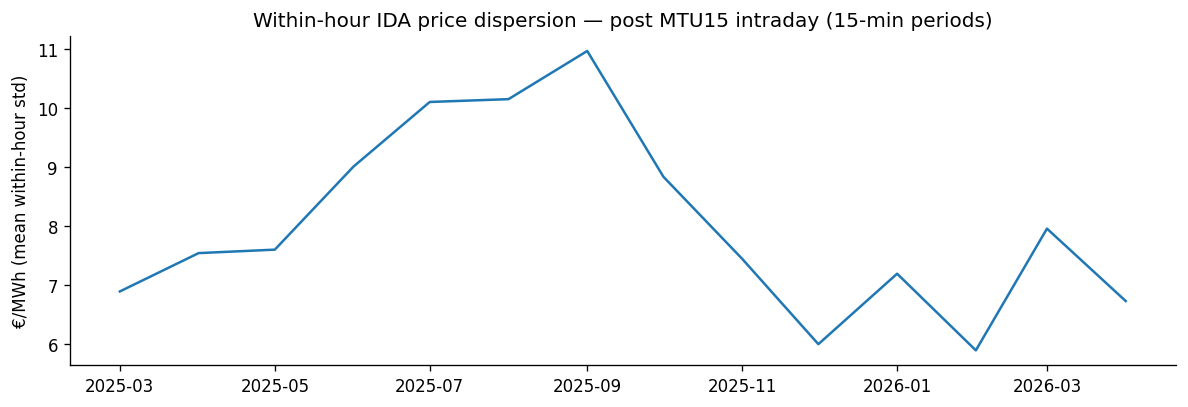

In [18]:
# Per-day within-hour std of IDA prices (across the 4 quarter-hour periods in each hour)
intra_hour2 = con.execute(f"""
    WITH post AS (
        SELECT
            date::DATE              AS date,
            CEIL(period / 4.0)::INT AS hour_block,
            STDDEV(price_es_eur_mwh) AS within_hour_std
        FROM read_parquet('{MARGINALPIBC}')
        WHERE date >= '{INTRADAY_REFORM.date()}'
          AND mtu_minutes = 15
        GROUP BY date::DATE, CEIL(period / 4.0)::INT
    )
    SELECT
        DATE_TRUNC('month', date)    AS month,
        AVG(within_hour_std)         AS mean_within_hour_std
    FROM post
    GROUP BY 1
    ORDER BY 1
""").df()

intra_hour2["month"] = pd.to_datetime(intra_hour2["month"])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(intra_hour2["month"], intra_hour2["mean_within_hour_std"], lw=1.5)
ax.set_ylabel("€/MWh (mean within-hour std)")
ax.set_title("Within-hour IDA price dispersion — post MTU15 intraday (15-min periods)")
plt.tight_layout()
plt.show()

### 2c. DA vs continuous intraday (MIBEL continuous) spread

`precios_pibcic_ronda` reports the mean transaction price $p^{CONT}_{thr}$ in each trading round $r$. Using the final round as the most informative signal:

$$\text{spread}^{cont}_{th} = p^{CONT}_{th,r_{\max}} - p^{DA}_{th}$$

The continuous market clears bilaterally throughout the day, so its price reflects the most up-to-date information about the delivery period. A positive spread ($p^{CONT} > p^{DA}$) is consistent with demand surprises resolved after DA closure.

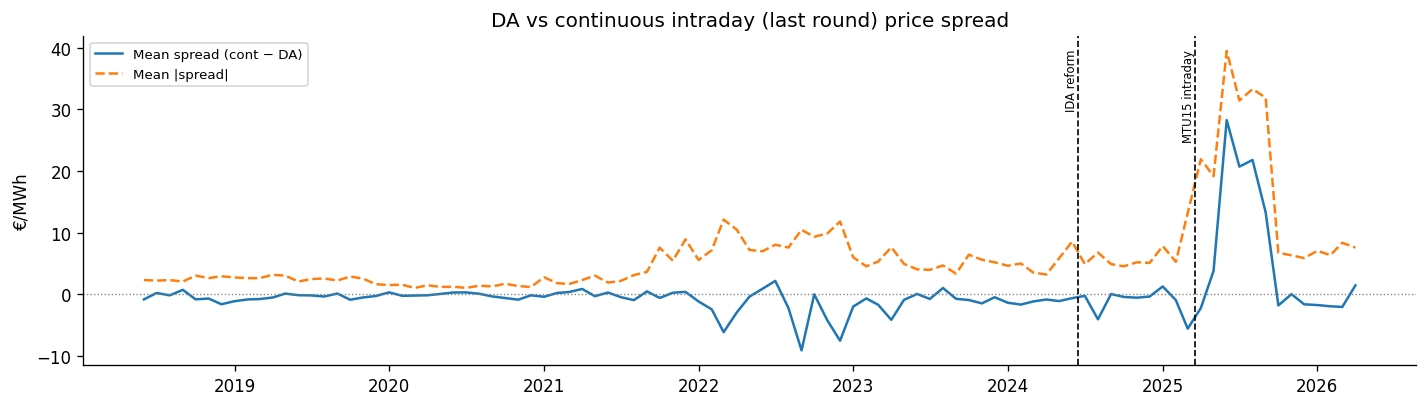

In [19]:
spread_cont = con.execute(f"""
    WITH da AS (
        SELECT date::DATE AS date, period, price_es_eur_mwh AS da_price
        FROM read_parquet('{MARGINALPDBC}')
    ),
    cont_last AS (
        SELECT
            date::DATE AS date, period,
            price_mean_es_eur_mwh AS cont_price,
            ROW_NUMBER() OVER (PARTITION BY date::DATE, period ORDER BY round_number DESC) AS rn
        FROM read_parquet('{PRECIOS_PIBCIC_RONDA}')
        WHERE price_mean_es_eur_mwh IS NOT NULL
    ),
    joined AS (
        SELECT
            da.date,
            da.period,
            da.da_price,
            cont.cont_price,
            (cont.cont_price - da.da_price) AS spread
        FROM da
        JOIN cont_last cont USING (date, period)
        WHERE cont.rn = 1
    )
    SELECT
        DATE_TRUNC('month', date) AS month,
        AVG(spread)               AS mean_spread,
        AVG(ABS(spread))          AS mean_abs_spread,
        STDDEV(spread)            AS std_spread
    FROM joined
    GROUP BY 1
    ORDER BY 1
""").df()

spread_cont["month"] = pd.to_datetime(spread_cont["month"])

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(spread_cont["month"], spread_cont["mean_spread"],     lw=1.5, label="Mean spread (cont − DA)")
ax.plot(spread_cont["month"], spread_cont["mean_abs_spread"], lw=1.5, ls="--", label="Mean |spread|")
ax.axhline(0, color="grey", lw=0.8, ls=":")
for d, label in [
    (IDA_REFORM,       "IDA reform"),
    (INTRADAY_REFORM,  "MTU15 intraday"),
]:
    ax.axvline(d, color="black", lw=1, ls="--")
    ax.text(d, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=7)
ax.set_ylabel("€/MWh")
ax.set_title("DA vs continuous intraday (last round) price spread")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2d. Arbitrage window: periods with large positive spread (cont > DA)

Define a binary arbitrage indicator for each (date, period):

$$a_{th} = \mathbf{1}\!\left[\text{spread}^{cont}_{th} > \delta\right]$$

for a threshold $\delta > 0$ (e.g. $\delta = 5$ €/MWh to exclude noise). The average arbitrage frequency by hour of day is

$$\bar{a}_{\hat{h}} = \frac{1}{|\mathcal{T}|}\sum_t a_{t\hat{h}}$$

Systematic patterns in $\bar{a}_{\hat{h}}$ (e.g. higher at peak hours) reveal predictable windows where buying in the DA and selling in the continuous market yields positive expected profit — a potential motive for the re-trading documented in Section 3.

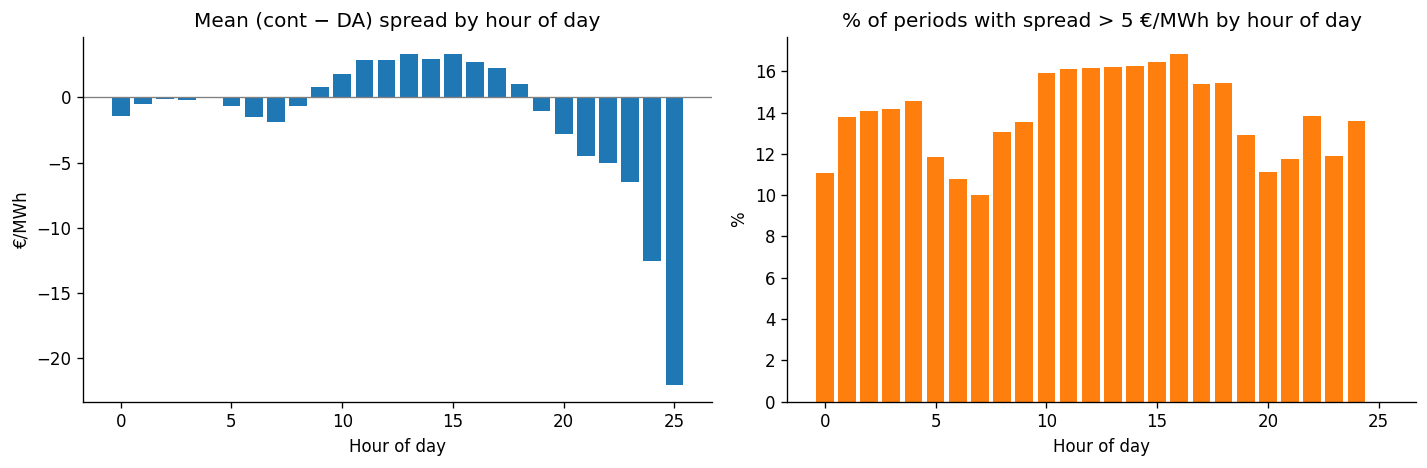

In [20]:
arb_profile = con.execute(f"""
    WITH da AS (
        SELECT date::DATE AS date, period, price_es_eur_mwh AS da_price, mtu_minutes
        FROM read_parquet('{MARGINALPDBC}')
    ),
    cont_last AS (
        SELECT
            date::DATE AS date, period,
            price_mean_es_eur_mwh AS cont_price,
            ROW_NUMBER() OVER (PARTITION BY date::DATE, period ORDER BY round_number DESC) AS rn
        FROM read_parquet('{PRECIOS_PIBCIC_RONDA}')
        WHERE price_mean_es_eur_mwh IS NOT NULL
    ),
    joined AS (
        SELECT
            da.date,
            da.period,
            da.mtu_minutes,
            -- Map period to hour-of-day (0-23) regardless of MTU
            CASE
                WHEN da.mtu_minutes = 60 THEN (da.period - 1)
                WHEN da.mtu_minutes = 15 THEN ((da.period - 1) / 4)
            END::INT AS hour_of_day,
            (cont.cont_price - da.da_price) AS spread
        FROM da
        JOIN cont_last cont USING (date, period)
        WHERE cont.rn = 1
    )
    SELECT
        hour_of_day,
        AVG(spread)              AS mean_spread,
        AVG(CASE WHEN spread > 0 THEN spread END) AS mean_pos_spread,
        AVG(CASE WHEN spread < 0 THEN spread END) AS mean_neg_spread,
        SUM(CASE WHEN spread > 5  THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct_above_5eur
    FROM joined
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(arb_profile["hour_of_day"], arb_profile["mean_spread"])
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("€/MWh")
ax.set_title("Mean (cont − DA) spread by hour of day")

ax = axes[1]
ax.bar(arb_profile["hour_of_day"], arb_profile["pct_above_5eur"], color="C1")
ax.set_xlabel("Hour of day")
ax.set_ylabel("%")
ax.set_title("% of periods with spread > 5 €/MWh by hour of day")

plt.tight_layout()
plt.show()

---
## Section 3 — Program reconciliation: who re-trades and how much?

**Question:** How much do agents adjust their day-ahead schedule in the intraday markets, and did the MTU15 reform change the volume or pattern of re-trading?

**Re-trading volume.** For unit $i$ on date $t$, total absolute intraday adjustment (MWh):

$$V^{retrade}_{it} = \tau\left(\sum_s\sum_h \left|\Delta Q^{IDA}_{iths}\right| + \sum_r\sum_h \left|\Delta Q^{CONT}_{ithr}\right|\right)$$

**Re-trading rate.** Normalised by the unit's day-ahead program volume:

$$\rho^{retrade}_{it} = \frac{V^{retrade}_{it}}{V^{DA}_{it}}, \qquad V^{DA}_{it} = \tau\sum_h \left|Q^{DA}_{ith}\right|$$

**Agent groups** (from Section 1e): Mostly sell ($\rho_g \geq 0.8$) — generators; Mostly buy ($\rho_g \leq 0.2$) — retailers; Mixed ($0.2 < \rho_g < 0.8$) — integrated utilities and portfolio traders. Mixed agents are the most active re-traders: they can exploit both sides of the spread.

### 3a. Daily re-trading volume over time

Daily aggregate re-trading volume:

$$V^{retrade}_t = \sum_i V^{retrade}_{it}$$

plotted alongside the total day-ahead program $V^{DA}_t = \sum_i V^{DA}_{it}$. The ratio $V^{retrade}_t / V^{DA}_t$ measures market-wide re-trading intensity — an increase post-MTU15 would indicate that the finer grid either creates more imbalance or opens more profitable re-trading windows.

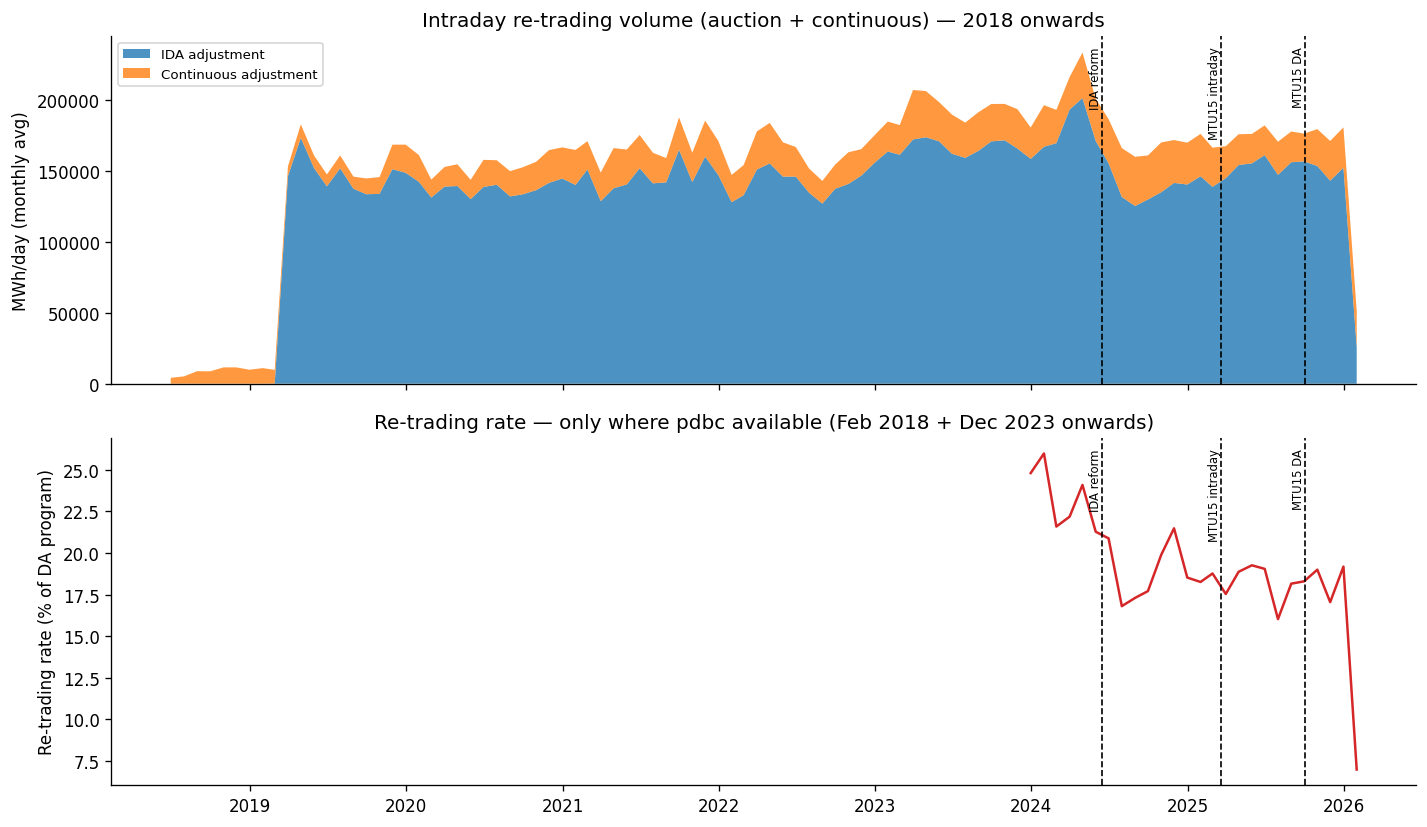

In [21]:
# Intraday auction adjustments (goes back to 2019)
ida_vol = con.execute(f"""
    SELECT date::DATE AS date,
           SUM(ABS(assigned_power_mw) * mtu_minutes / 60.0) AS ida_mwh
    FROM read_parquet('{PIBCI}')
    GROUP BY date::DATE ORDER BY date::DATE
""").df()

# Continuous intraday adjustments (goes back to 2018-06)
cont_vol = con.execute(f"""
    SELECT date::DATE AS date,
           SUM(ABS(assigned_power_mw) * mtu_minutes / 60.0) AS cont_mwh
    FROM read_parquet('{PIBCIC}')
    GROUP BY date::DATE ORDER BY date::DATE
""").df()

# Day-ahead program (pdbc) — only available Feb 2018 + Dec 2023 onwards
da_vol = con.execute(f"""
    SELECT date::DATE AS date,
           SUM(ABS(assigned_power_mw) * mtu_minutes / 60.0) AS da_mwh
    FROM read_parquet('{PDBC}')
    GROUP BY date::DATE ORDER BY date::DATE
""").df()

# Volume base: outer merge of pibci + pibcic so we get full history
retrade_vol = (
    ida_vol
    .merge(cont_vol, on="date", how="outer")
    .fillna({"ida_mwh": 0, "cont_mwh": 0})
    .sort_values("date")
)
retrade_vol["date"] = pd.to_datetime(retrade_vol["date"])
retrade_vol["retrade_mwh"] = retrade_vol["ida_mwh"] + retrade_vol["cont_mwh"]

# Re-trading rate: requires pdbc; only defined where pdbc has coverage
recon = retrade_vol.merge(da_vol, on="date", how="left")
recon["retrade_rate"] = recon["retrade_mwh"] / recon["da_mwh"]

# Monthly averages
retrade_m = retrade_vol.set_index("date").resample("ME").mean().reset_index()
recon_m   = recon.set_index("date").resample("ME").mean().reset_index()

REFORM_LINES = [
    (IDA_REFORM,       "IDA reform"),
    (INTRADAY_REFORM,  "MTU15 intraday"),
    (DAY_AHEAD_REFORM, "MTU15 DA"),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.stackplot(retrade_m["date"], retrade_m["ida_mwh"], retrade_m["cont_mwh"],
             labels=["IDA adjustment", "Continuous adjustment"], alpha=0.8)
ax.set_ylabel("MWh/day (monthly avg)")
ax.set_title("Intraday re-trading volume (auction + continuous) — 2018 onwards")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(recon_m["date"], recon_m["retrade_rate"] * 100, lw=1.5, color="C3")
ax.set_ylabel("Re-trading rate (% of DA program)")
ax.set_title("Re-trading rate — only where pdbc available (Feb 2018 + Dec 2023 onwards)")

for ax in axes:
    for d, label in REFORM_LINES:
        ax.axvline(d, color="black", lw=1, ls="--")
        ax.text(d, 0.97, label, transform=ax.get_xaxis_transform(),
                rotation=90, va="top", ha="right", fontsize=7)

plt.tight_layout()
plt.show()

### 3b. Re-trading by agent group

Group-level re-trading volume in regime $\mathcal{R}$ (pre or post MTU15):

$$V^{retrade}_{g,\mathcal{R}} = \sum_{t \in \mathcal{R}}\sum_{i \in \mathcal{U}_g} V^{retrade}_{it}$$

Compares absolute MWh re-traded across Mostly sell / Mixed / Mostly buy before and after $t^* = \text{2025-03-19}$. A disproportionate increase in Mixed agents post-reform is consistent with traders exploiting the new 15-min price signals.
> Requires `agent_agg` from Section 1e.

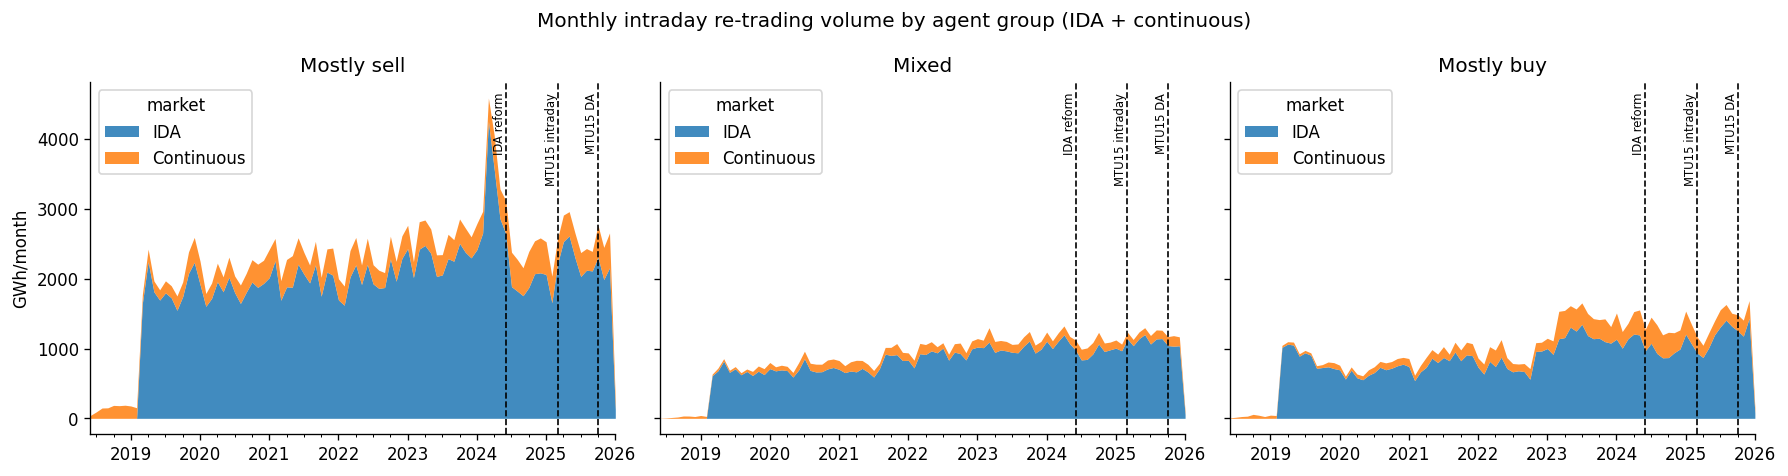

In [22]:
REFORM_STR = INTRADAY_REFORM.date().isoformat()

# Register agent classification as a DuckDB table for SQL joins
con.register("agent_groups", agent_agg[["agent", "group"]])

# Register lista_unidades so DuckDB can join unit_code → owner_agent → group
con.register("units_df", units[["unit_code", "owner_agent"]])

retrade_by_group = con.execute(f"""
    WITH combined AS (
        SELECT date::DATE AS date, unit_code,
               ABS(assigned_power_mw) * mtu_minutes / 60.0 AS mwh,
               'IDA' AS market
        FROM read_parquet('{PIBCI}')
        UNION ALL
        SELECT date::DATE AS date, unit_code,
               ABS(assigned_power_mw) * mtu_minutes / 60.0 AS mwh,
               'Continuous' AS market
        FROM read_parquet('{PIBCIC}')
    ),
    with_group AS (
        SELECT
            c.date,
            c.mwh,
            c.market,
            COALESCE(ag.group, 'Unknown') AS agent_group
        FROM combined c
        LEFT JOIN units_df     u  ON c.unit_code  = u.unit_code
        LEFT JOIN agent_groups ag ON u.owner_agent = ag.agent
    )
    SELECT
        DATE_TRUNC('month', date) AS month,
        agent_group,
        market,
        SUM(mwh)                  AS total_mwh
    FROM with_group
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

retrade_by_group["month"] = retrade_by_group["month"].astype("datetime64[ns]")

colors_market = {"IDA": "C0", "Continuous": "C1"}

REFORM_LINES = [
    (IDA_REFORM,       "IDA reform"),
    (INTRADAY_REFORM,  "MTU15 intraday"),
    (DAY_AHEAD_REFORM, "MTU15 DA"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, grp in zip(axes, ["Mostly sell", "Mixed", "Mostly buy"]):
    sub = retrade_by_group[retrade_by_group["agent_group"] == grp]
    pivot = sub.pivot_table(index="month", columns="market", values="total_mwh", aggfunc="sum").fillna(0)
    pivot = pivot.reindex(columns=["IDA", "Continuous"], fill_value=0)
    pivot.div(1e3).plot.area(ax=ax, color=[colors_market.get(c, "grey") for c in pivot.columns],
                             linewidth=0, alpha=0.85)
    ax.set_title(grp)
    ax.set_xlabel("")
    ax.set_ylabel("GWh/month" if ax == axes[0] else "")
    for d, label in REFORM_LINES:
        ax.axvline(d, color="black", lw=1, ls="--")
        ax.text(d, 0.97, label, transform=ax.get_xaxis_transform(),
                rotation=90, va="top", ha="right", fontsize=7)

plt.suptitle("Monthly intraday re-trading volume by agent group (IDA + continuous)")
plt.tight_layout()
plt.show()

### 3c. Re-trading rate by agent group pre vs post MTU15

Group-level re-trading rate in regime $\mathcal{R}$:

$$\bar{\rho}^{retrade}_{g,\mathcal{R}} = \frac{\displaystyle\sum_{t\in\mathcal{R}}\sum_{i\in\mathcal{U}_g} V^{retrade}_{it}}{\displaystyle\sum_{t\in\mathcal{R}}\sum_{i\in\mathcal{U}_g} V^{DA}_{it}}$$

Normalising by the DA program controls for the fact that some groups are simply larger. An increase in $\bar{\rho}^{retrade}_{g,\text{post}} - \bar{\rho}^{retrade}_{g,\text{pre}}$ for a given group indicates that the MTU15 reform induced more intensive re-trading relative to their baseline DA position.

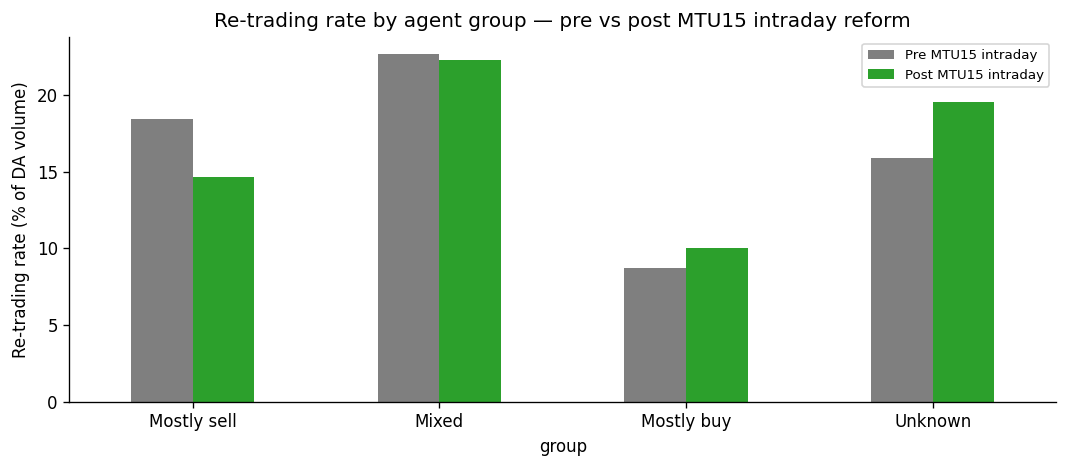

pre_post     Pre MTU15 intraday  Post MTU15 intraday
group                                               
Mostly sell                18.4                 14.6
Mixed                      22.6                 22.3
Mostly buy                  8.7                 10.0
Unknown                    15.9                 19.5


In [23]:
# DA program by unit
da_by_unit = con.execute(f"""
    SELECT
        date::DATE AS date,
        unit_code,
        SUM(ABS(assigned_power_mw) * mtu_minutes / 60.0) AS da_mwh
    FROM read_parquet('{PDBC}')
    GROUP BY date::DATE, unit_code
""").df()

# Intraday adjustment by unit
retrade_by_unit = con.execute(f"""
    WITH combined AS (
        SELECT date::DATE AS date, unit_code,
               ABS(assigned_power_mw) * mtu_minutes / 60.0 AS mwh
        FROM read_parquet('{PIBCI}')
        UNION ALL
        SELECT date::DATE AS date, unit_code,
               ABS(assigned_power_mw) * mtu_minutes / 60.0 AS mwh
        FROM read_parquet('{PIBCIC}')
    )
    SELECT date, unit_code, SUM(mwh) AS retrade_mwh
    FROM combined
    GROUP BY date, unit_code
""").df()

# Merge and add group
unit_to_group = (
    units[["unit_code", "owner_agent"]]
    .merge(agent_agg[["agent", "group"]], left_on="owner_agent", right_on="agent", how="left")
    [["unit_code", "group"]]
    .fillna({"group": "Unknown"})
)

rate_df = (
    da_by_unit
    .merge(retrade_by_unit, on=["date", "unit_code"], how="left")
    .fillna({"retrade_mwh": 0})
    .merge(unit_to_group, on="unit_code", how="left")
    .fillna({"group": "Unknown"})
)
rate_df["date"] = pd.to_datetime(rate_df["date"])
rate_df["pre_post"] = rate_df["date"].apply(
    lambda d: "Post MTU15 intraday" if d >= INTRADAY_REFORM else "Pre MTU15 intraday"
)

# Mean re-trading rate per group × period
summary = (
    rate_df.groupby(["group", "pre_post"])[["da_mwh", "retrade_mwh"]]
    .sum()
    .reset_index()
)
summary["rate_pct"] = summary["retrade_mwh"] / summary["da_mwh"] * 100

order = ["Mostly sell", "Mixed", "Mostly buy", "Unknown"]
summary["group"] = pd.Categorical(summary["group"], categories=order, ordered=True)
summary = summary.sort_values(["group", "pre_post"])

pivot_rate = summary.pivot_table(index="group", columns="pre_post", values="rate_pct")
pivot_rate = pivot_rate[["Pre MTU15 intraday", "Post MTU15 intraday"]]

ax = pivot_rate.plot.bar(figsize=(9, 4), rot=0, color=["C7", "C2"])
ax.set_ylabel("Re-trading rate (% of DA volume)")
ax.set_title("Re-trading rate by agent group — pre vs post MTU15 intraday reform")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(pivot_rate.round(1).to_string())

### 3d. Intra-day adjustment profile by agent group and hour of day

Average re-trading volume per hour-of-day $\hat{h}$ for agent group $g$:

$$\bar{v}_{g,\hat{h}} = \frac{1}{|\mathcal{T}|}\sum_{t}\sum_{i\in\mathcal{U}_g}\sum_{h\in\hat{h}} \left(\sum_s\left|\Delta Q^{IDA}_{iths}\right| + \sum_r\left|\Delta Q^{CONT}_{ithr}\right|\right)\cdot\tau$$

where the inner sum over $h \in \hat{h}$ accumulates quarter-hour MTUs within the same clock-hour. A concentration of $\bar{v}_{g,\hat{h}}$ in peak hours for Mixed agents is consistent with arbitrage-driven behaviour: traders re-trade most when the price spread is widest.

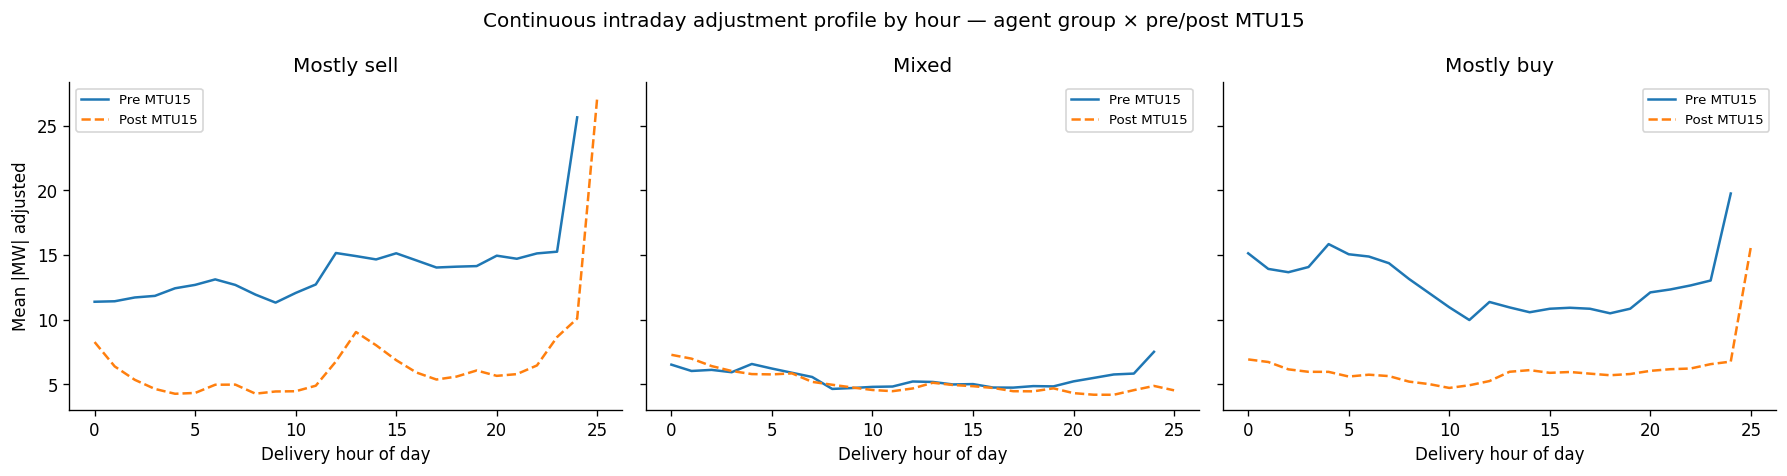

In [24]:
profile_group = con.execute(f"""
    WITH combined AS (
        SELECT
            date::DATE              AS date,
            unit_code,
            CASE
                WHEN mtu_minutes = 60 THEN (period - 1)
                WHEN mtu_minutes = 15 THEN ((period - 1) / 4)
            END::INT                AS hour_of_day,
            ABS(assigned_power_mw)  AS abs_mw
        FROM read_parquet('{PIBCIC}')
    ),
    with_group AS (
        SELECT
            c.date, c.hour_of_day, c.abs_mw,
            COALESCE(ag.group, 'Unknown') AS agent_group
        FROM combined c
        LEFT JOIN units_df     u  ON c.unit_code  = u.unit_code
        LEFT JOIN agent_groups ag ON u.owner_agent = ag.agent
    )
    SELECT
        agent_group,
        CASE WHEN date >= '{INTRADAY_REFORM.date()}' THEN 'Post MTU15' ELSE 'Pre MTU15' END AS period,
        hour_of_day,
        AVG(abs_mw) AS mean_abs_mw
    FROM with_group
    WHERE agent_group IN ('Mostly sell', 'Mixed', 'Mostly buy')
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, grp in zip(axes, ["Mostly sell", "Mixed", "Mostly buy"]):
    sub = profile_group[profile_group["agent_group"] == grp]
    for period_label, ls in [("Pre MTU15", "-"), ("Post MTU15", "--")]:
        s = sub[sub["period"] == period_label]
        ax.plot(s["hour_of_day"], s["mean_abs_mw"], lw=1.5, ls=ls, label=period_label)
    ax.set_title(grp)
    ax.set_xlabel("Delivery hour of day")
    ax.set_ylabel("Mean |MW| adjusted" if ax == axes[0] else "")
    ax.legend(fontsize=8)

plt.suptitle("Continuous intraday adjustment profile by hour — agent group × pre/post MTU15")
plt.tight_layout()
plt.show()

---
## Section 4 — Bid price anatomy and market power (intraday auctions)

**Notation.** Index units by $i$, dates by $t$, sessions by $s \in \{1,2,3\}$, periods (MTUs) by $h$, and supply-curve tranches by $k$. Each matched tranche in `idet` carries a bid price $p_{ithsk}$ (€/MWh) and cleared quantity $q_{ithsk}$ (MW). The uniform clearing price from `marginalpibc` is $P_{ths}$ (€/MWh). MTU duration is $\tau = \text{mtu\_minutes}/60$ hours (1 h pre-MTU15, 0.25 h post-MTU15).

**Research questions:**
1. **4a — Cost heterogeneity.** Does the distribution of effective bid prices differ by technology, as predicted by cost theory?
2. **4b — Infra-marginal rents.** How large is the producer surplus $\max(P_{ths} - p_{ithsk}, 0)\cdot q_{ithsk}\cdot\tau$ earned by each technology under the uniform-price rule?
3. **4c — Sequential learning.** Do units revise bids upward between sessions after observing the session-1 clearing price?
4. **4d — Conduct test.** Is there a positive reduced-form relationship between a unit's market share and its bid price, consistent with oligopolistic conduct?

All cells use sell-side matched offers from `idet` + `icab`, joined with `marginalpibc`. Cross-session analysis is restricted to post-IDA reform data ($\geq$ 2024-06-14).

In [25]:
IDA_REFORM_STR      = IDA_REFORM.date().isoformat()
INTRADAY_REFORM_STR = INTRADAY_REFORM.date().isoformat()
# Cells 4a and 4b each run their own DuckDB aggregation query and pull only
# the small summary into pandas — no full join materialised in Python.

### 4a. Offer price distribution by technology

**Supply-curve structure.** For each (unit $i$, date $t$, session $s$, period $h$), a matched offer in `idet` consists of $K_{iths}$ tranches — a step function $\{(p_{ithsk}, q_{ithsk})\}_{k=1}^{K_{iths}}$. The raw `price_eur_mwh` field is the tranche price $p_{ithsk}$, not an offer-level summary.

**Quantity-weighted average bid price.** To obtain one economically meaningful observation per (unit, session, period) we collapse tranches using the MW-weighted average:

$$\bar{p}_{iths} = \frac{\displaystyle\sum_{k=1}^{K_{iths}} p_{ithsk}\, q_{ithsk}}{\displaystyle\sum_{k=1}^{K_{iths}} q_{ithsk}}$$

This is the effective price at which unit $i$ supplies to period $h$ — the marginal cost of the average cleared MWh. Unweighted averages would over-count small high-price tranches and under-count large low-price tranches.

**Expected pattern.** Wind and Solar PV have near-zero variable cost, so $\bar{p}_{iths} \approx 0$. CCGT and Coal face positive fuel costs; their bids satisfy $\bar{p}_{iths} \geq c_i^{\text{fuel}}$ with possible strategic mark-up. Pumped hydro bids reflect opportunity cost of stored water.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 33,192,783


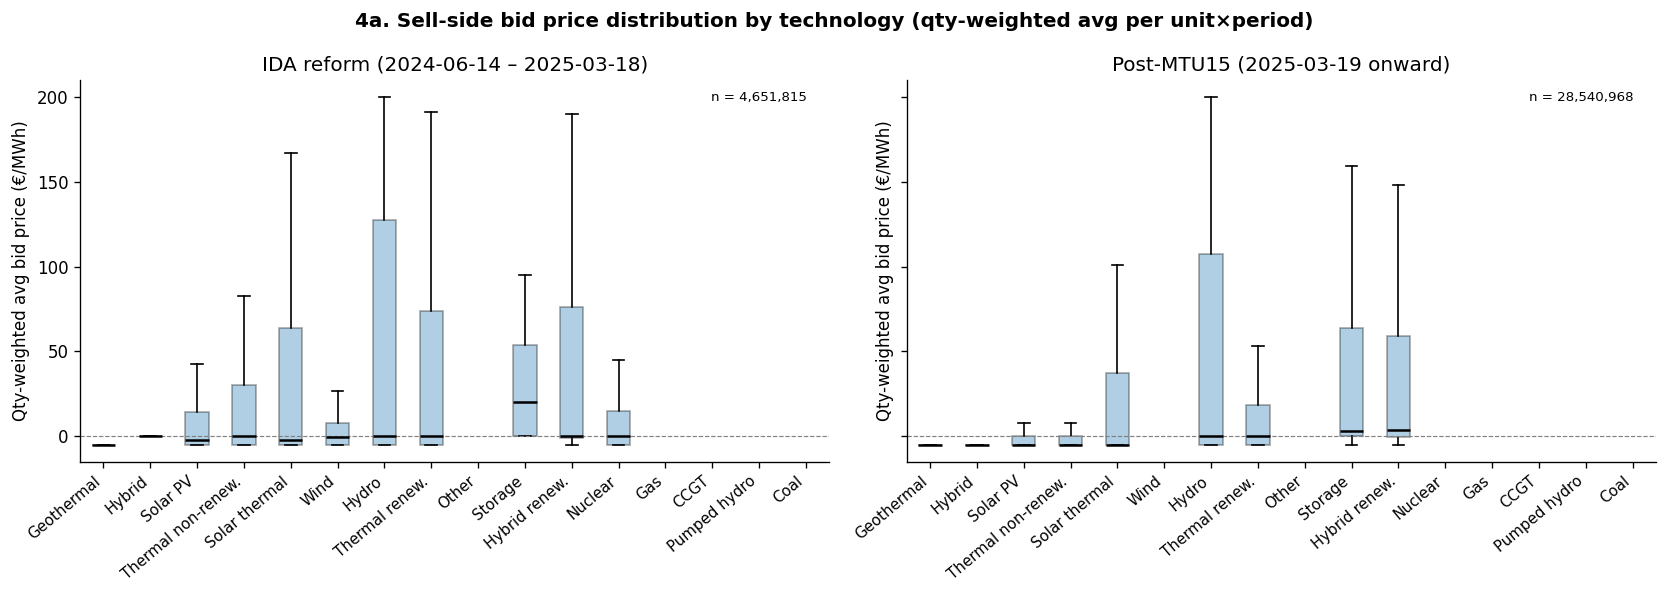

In [26]:
# Quantity-weighted avg bid price per (unit, session, period) — all in DuckDB.
# SELECT returns one row per unit×period; only 3 columns pulled into pandas.
bids_4a = con.execute(f"""
    WITH icab_sell AS (
        SELECT date::DATE AS date, session_number, offer_code, unit_code
        FROM read_parquet('{ICAB}')
        WHERE buy_sell = 'V'
          AND date::DATE >= '{IDA_REFORM_STR}'
    ),
    tech_lkp AS (
        SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
    )
    SELECT
        CASE WHEN d.date::DATE >= '{INTRADAY_REFORM_STR}'
             THEN 'Post-MTU15' ELSE 'IDA reform' END                AS regime,
        COALESCE(tm.technology, 'Unknown')                          AS technology,
        SUM(d.price_eur_mwh * d.quantity_mw)
          / NULLIF(SUM(d.quantity_mw), 0)                          AS wavg_bid
    FROM read_parquet('{IDET}') d
    JOIN icab_sell o
        ON  d.date::DATE     = o.date
        AND d.session_number = o.session_number
        AND d.offer_code     = o.offer_code
    LEFT JOIN tech_lkp tm ON tm.unit_code = o.unit_code
    WHERE d.date::DATE >= '{IDA_REFORM_STR}'
    GROUP BY
        CASE WHEN d.date::DATE >= '{INTRADAY_REFORM_STR}'
             THEN 'Post-MTU15' ELSE 'IDA reform' END,
        COALESCE(tm.technology, 'Unknown'),
        d.date::DATE, d.session_number, d.period, o.unit_code
""").df()

bids_4a["tech_group"] = bids_4a["technology"].map(TECH_MAP).fillna("Other")
print(f"Rows: {len(bids_4a):,}")

# Keep technology groups with >= 500 unit×period observations
tech_counts = bids_4a.groupby("tech_group")["wavg_bid"].count()
top_techs   = tech_counts[tech_counts >= 500].index.tolist()
plot_df     = bids_4a[bids_4a["tech_group"].isin(top_techs)].copy()

tech_order_4a = (
    plot_df.groupby("tech_group")["wavg_bid"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, regime, window in zip(
    axes,
    ["IDA reform", "Post-MTU15"],
    ["2024-06-14 – 2025-03-18", "2025-03-19 onward"],
):
    sub  = plot_df[plot_df["regime"] == regime]
    data = [sub.loc[sub["tech_group"] == t, "wavg_bid"].clip(-5, 200).values
            for t in tech_order_4a]
    bp   = ax.boxplot(data, vert=True, showfliers=False, patch_artist=True,
                      medianprops={"color": "black", "linewidth": 1.5})
    for patch in bp["boxes"]:
        patch.set_facecolor("C0")
        patch.set_alpha(0.35)
    ax.set_xticks(range(1, len(tech_order_4a) + 1))
    ax.set_xticklabels(tech_order_4a, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Qty-weighted avg bid price (€/MWh)")
    ax.set_title(f"{regime} ({window})")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
    ax.text(0.97, 0.97, f"n = {len(sub):,}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8)

fig.suptitle(
    "4a. Sell-side bid price distribution by technology (qty-weighted avg per unit×period)",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

### 4b. Infra-marginal rent by technology

**Uniform-price clearing.** The intraday auction clears at a single price $P_{ths}$ per (session, period). Every accepted offer earns this price regardless of its bid. The **infra-marginal markup** of tranche $k$ is

$$m_{ithsk} = \max\!\left(P_{ths} - p_{ithsk},\; 0\right) \quad (\text{€/MWh})$$

and the **infra-marginal rent** (producer surplus) earned by that tranche is

$$R_{ithsk} = m_{ithsk} \cdot q_{ithsk} \cdot \tau \quad (\text{€})$$

where $\tau = \text{mtu\_minutes}/60$. Aggregating over all tranches, periods, and sessions gives the total rent for unit $i$ on date $t$:

$$R_{it} = \sum_{s}\sum_{h}\sum_{k} R_{ithsk}$$

**Average markup.** The bars in the left panel show $\bar{m} = N^{-1}\sum m_{ithsk}$ across all matched tranches of a given technology and regime — a tranche-level average, not a unit-level one.

**Key change post-MTU15.** The reform multiplies the number of periods from 25 to 100. If intra-hour price dispersion is small, rents per MWh are largely unaffected; if not, 15-minute clearing reveals within-hour variation that the hourly auction averaged away, potentially redistributing rents.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

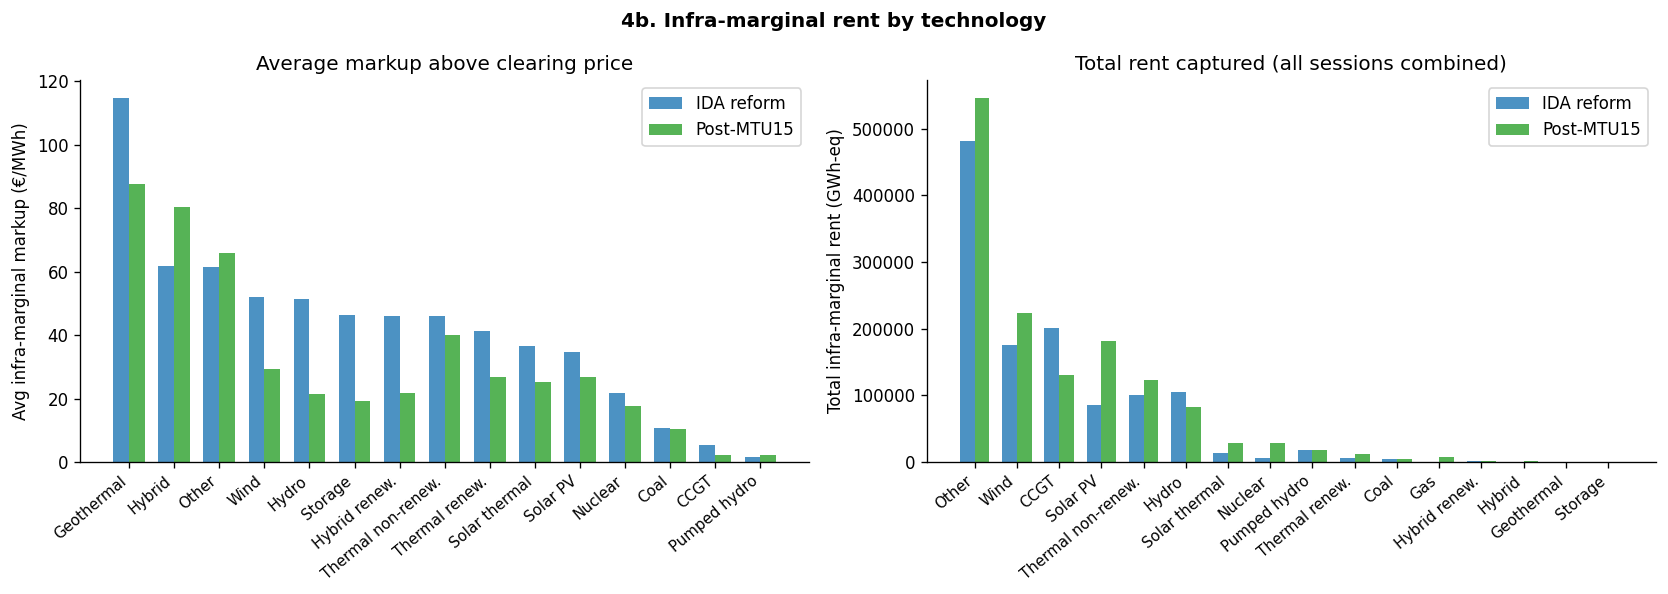

    regime         tech_group  avg_markup  med_markup  total_rent_gwh
IDA reform         Geothermal  114.672242  117.280000        8.543082
IDA reform             Hybrid   61.733253   69.900000      232.840814
IDA reform              Other   61.354716   51.575313   482119.789053
IDA reform               Wind   51.985735   44.785000   175784.983378
IDA reform              Hydro   51.507141   54.941667   105546.152674
IDA reform            Storage   46.395000   47.590000        0.861416
IDA reform      Hybrid renew.   46.137517   46.722500     1880.298538
IDA reform Thermal non-renew.   46.081358   46.800000   100029.564314
IDA reform     Thermal renew.   41.220182   15.875000     5510.113305
IDA reform      Solar thermal   36.462054    9.990000    12874.305112
IDA reform           Solar PV   34.831342   23.177500    85539.008937
IDA reform            Nuclear   21.860679   10.000000     6225.224369
IDA reform               Coal   10.634517    0.000000     4018.601917
IDA reform          

In [27]:
# Infra-marginal markup aggregated entirely in DuckDB.
# Result is one row per (regime, technology) — no large DataFrame in Python.
markup_4b = con.execute(f"""
    WITH icab_sell AS (
        SELECT date::DATE AS date, session_number, offer_code, unit_code
        FROM read_parquet('{ICAB}')
        WHERE buy_sell = 'V'
          AND date::DATE >= '{IDA_REFORM_STR}'
    ),
    clearing AS (
        SELECT date::DATE AS date, session_number, period, price_es_eur_mwh AS clr_price
        FROM read_parquet('{MARGINALPIBC}')
        WHERE date::DATE >= '{IDA_REFORM_STR}'
    ),
    tech_lkp AS (
        SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
    )
    SELECT
        CASE WHEN d.date::DATE >= '{INTRADAY_REFORM_STR}'
             THEN 'Post-MTU15' ELSE 'IDA reform' END                          AS regime,
        COALESCE(tm.technology, 'Unknown')                                    AS technology,
        AVG(GREATEST(c.clr_price - d.price_eur_mwh, 0))                      AS avg_markup,
        MEDIAN(GREATEST(c.clr_price - d.price_eur_mwh, 0))                   AS med_markup,
        SUM(GREATEST(c.clr_price - d.price_eur_mwh, 0)
            * d.quantity_mw * d.mtu_minutes / 60.0) / 1e3                    AS total_rent_gwh,
        COUNT(*)                                                               AS n_obs
    FROM read_parquet('{IDET}') d
    JOIN icab_sell o
        ON  d.date::DATE     = o.date
        AND d.session_number = o.session_number
        AND d.offer_code     = o.offer_code
    JOIN clearing c
        ON  d.date::DATE     = c.date
        AND d.session_number = c.session_number
        AND d.period         = c.period
    LEFT JOIN tech_lkp tm ON tm.unit_code = o.unit_code
    WHERE d.date::DATE >= '{IDA_REFORM_STR}'
    GROUP BY 1, 2
""").df()

markup_4b["tech_group"] = markup_4b["technology"].map(TECH_MAP).fillna("Other")
markup_by_tech = (
    markup_4b.groupby(["tech_group", "regime"])
    .agg(avg_markup=("avg_markup","mean"), med_markup=("med_markup","mean"),
         total_rent_gwh=("total_rent_gwh","sum"), n_obs=("n_obs","sum"))
    .reset_index()
)

keep = markup_by_tech.groupby("tech_group")["n_obs"].sum()
keep = keep[keep >= 500].index
markup_by_tech = markup_by_tech[markup_by_tech["tech_group"].isin(keep)]

tech_order_4b = (
    markup_by_tech[markup_by_tech["regime"] == "IDA reform"]
    .set_index("tech_group")["avg_markup"]
    .reindex(keep).sort_values(ascending=False).dropna().index.tolist()
)

regimes = ["IDA reform", "Post-MTU15"]
colors  = ["C0", "C2"]
width   = 0.35
x       = range(len(tech_order_4b))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (regime, color) in enumerate(zip(regimes, colors)):
    sub  = markup_by_tech[markup_by_tech["regime"] == regime].set_index("tech_group")
    vals = [sub.loc[t, "avg_markup"] if t in sub.index else 0 for t in tech_order_4b]
    axes[0].bar([xi + i * width for xi in x], vals, width=width,
                label=regime, color=color, alpha=0.8)
axes[0].set_xticks([xi + width / 2 for xi in x])
axes[0].set_xticklabels(tech_order_4b, rotation=40, ha="right", fontsize=9)
axes[0].set_ylabel("Avg infra-marginal markup (€/MWh)")
axes[0].set_title("Average markup above clearing price")
axes[0].legend()

rent_order = (
    markup_by_tech.groupby("tech_group")["total_rent_gwh"].sum()
    .sort_values(ascending=False).index.tolist()
)
x2 = range(len(rent_order))
for i, (regime, color) in enumerate(zip(regimes, colors)):
    sub  = markup_by_tech[markup_by_tech["regime"] == regime].set_index("tech_group")
    vals = [sub.loc[t, "total_rent_gwh"] if t in sub.index else 0 for t in rent_order]
    axes[1].bar([xi + i * width for xi in x2], vals, width=width,
                label=regime, color=color, alpha=0.8)
axes[1].set_xticks([xi + width / 2 for xi in x2])
axes[1].set_xticklabels(rent_order, rotation=40, ha="right", fontsize=9)
axes[1].set_ylabel("Total infra-marginal rent (GWh-eq)")
axes[1].set_title("Total rent captured (all sessions combined)")
axes[1].legend()

fig.suptitle("4b. Infra-marginal rent by technology", fontweight="bold")
fig.tight_layout()
plt.show()

print(markup_by_tech.sort_values(["regime","avg_markup"], ascending=[True,False])
      [["regime","tech_group","avg_markup","med_markup","total_rent_gwh"]]
      .to_string(index=False))

### 4c. Cross-session bid price revision

**Session-level average bid.** For unit $i$ on date $t$, define the average bid price in session $s$ as

$$\tilde{p}_{its} = \frac{1}{|\mathcal{H}_{its}|}\sum_{h \in \mathcal{H}_{its}} \text{AVG}_k(p_{ithsk})$$

where $\mathcal{H}_{its}$ is the set of periods in which unit $i$ was matched in session $s$ on date $t$. (The SQL uses `AVG(price_eur_mwh)` — an unweighted average across periods and tranches — which is sufficient to detect the direction of revision.)

**Revision statistic.** For pairs of sessions $s < s'$, the bid revision is

$$\Delta_{it}^{s'\leftarrow s} = \tilde{p}_{its'} - \tilde{p}_{its}$$

restricting to $(i,t)$ pairs for which the unit was matched in both sessions, i.e. $(i,t) \in \mathcal{I}_{ss'} \equiv \{(i,t) : \tilde{p}_{its}\text{ and }\tilde{p}_{its'}\text{ both defined}\}$.

**Null hypothesis.** Under the null of no strategic inter-session adjustment, $\mathbb{E}[\Delta_{it}^{s'\leftarrow s}] = 0$. A positive mean revision is consistent with **upward price discovery**: after observing a high $P_{t,h,1}$, units raise bids for the residual demand in session 2. A negative revision is consistent with urgency-driven discounting to clear remaining imbalance positions.

Unit×day pairs with s1 ∩ s2 data: 375,699

  Δ S2 − S1: mean=-5.45, median=0.00, pct>0=25.8%, pct<0=42.7%

  Δ S3 − S1: mean=-9.08, median=0.00, pct>0=24.5%, pct<0=45.2%


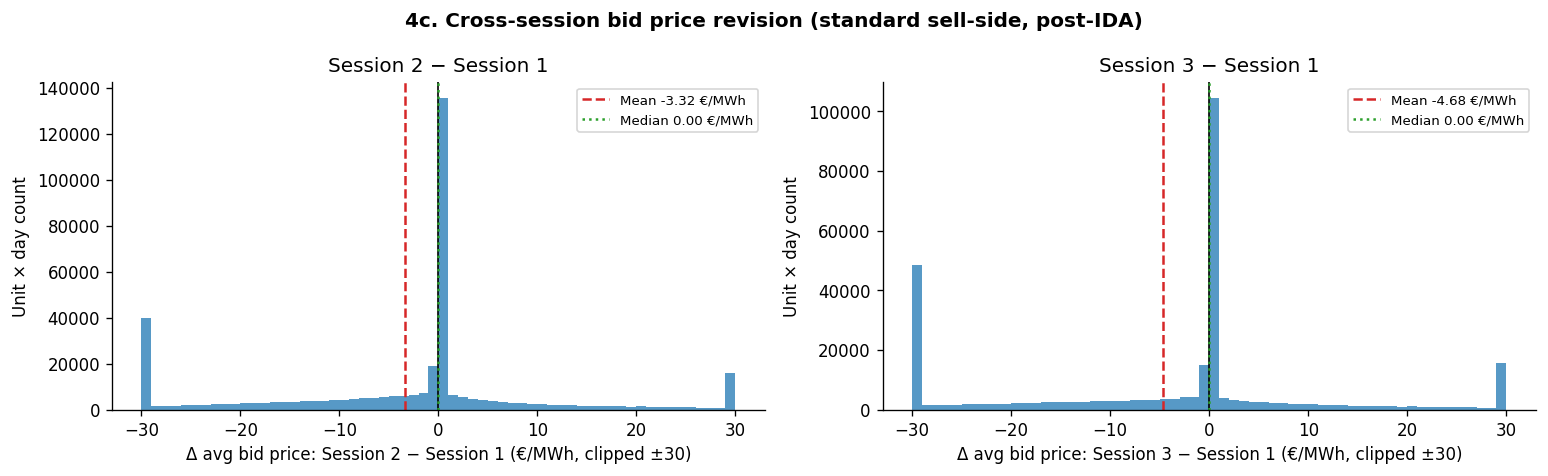

In [28]:
IDA_REFORM_STR = IDA_REFORM.date().isoformat()

# Unit-level average bid price per (date, session) — standard sell-side only
session_bids = con.execute(f"""
    WITH offers AS (
        -- Read icab directly; 'Simple'+'Block Order' = NOT one of the special need_type codes
        SELECT date::DATE AS date, session_number, offer_code, unit_code
        FROM read_parquet('{ICAB}')
        WHERE buy_sell = 'V'
          AND date::DATE >= '{IDA_REFORM_STR}'
          AND need_type NOT IN ('N 7', '70', '113',
                                'N 5', '50', '111',
                                'N 6', '61', 'N 8', '81', '90', '101', '102', '103', 'N 9')
    )
    SELECT
        d.date::DATE                                                    AS date,
        d.session_number,
        o.unit_code,
        AVG(d.price_eur_mwh)                                           AS avg_bid,
        SUM(d.quantity_mw * d.mtu_minutes / 60.0)                     AS tot_mwh
    FROM read_parquet('{IDET}') d
    JOIN offers o
        ON  d.date::DATE     = o.date
        AND d.session_number = o.session_number
        AND d.offer_code     = o.offer_code
    WHERE d.date::DATE >= '{IDA_REFORM_STR}'
    GROUP BY d.date::DATE, d.session_number, o.unit_code
""").df()

session_bids["date"] = pd.to_datetime(session_bids["date"])

# Pivot to sessions 1, 2, 3
s1 = session_bids[session_bids["session_number"] == 1].set_index(["date", "unit_code"])["avg_bid"].rename("s1")
s2 = session_bids[session_bids["session_number"] == 2].set_index(["date", "unit_code"])["avg_bid"].rename("s2")
s3 = session_bids[session_bids["session_number"] == 3].set_index(["date", "unit_code"])["avg_bid"].rename("s3")

revision = pd.concat([s1, s2, s3], axis=1).dropna(subset=["s1", "s2"])
revision["delta_s2_s1"] = revision["s2"] - revision["s1"]
revision["delta_s3_s1"] = (revision["s3"] - revision["s1"]).where(revision["s3"].notna())

print(f"Unit×day pairs with s1 ∩ s2 data: {len(revision):,}")
for col, label in [("delta_s2_s1", "S2 − S1"), ("delta_s3_s1", "S3 − S1")]:
    d = revision[col].dropna()
    pct_up  = (d > 0).mean() * 100
    pct_dn  = (d < 0).mean() * 100
    print(f"\n  Δ {label}: mean={d.mean():.2f}, median={d.median():.2f}, "
          f"pct>0={pct_up:.1f}%, pct<0={pct_dn:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in [
    (axes[0], "delta_s2_s1", "Session 2 − Session 1"),
    (axes[1], "delta_s3_s1", "Session 3 − Session 1"),
]:
    data = revision[col].dropna().clip(-30, 30)
    ax.hist(data, bins=60, color="C0", alpha=0.75, edgecolor="none")
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(data.mean(),   color="C3", linewidth=1.5, linestyle="--",
               label=f"Mean {data.mean():.2f} €/MWh")
    ax.axvline(data.median(), color="C2", linewidth=1.5, linestyle=":",
               label=f"Median {data.median():.2f} €/MWh")
    ax.set_xlabel(f"Δ avg bid price: {label} (€/MWh, clipped ±30)")
    ax.set_ylabel("Unit × day count")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle("4c. Cross-session bid price revision (standard sell-side, post-IDA)", fontweight="bold")
fig.tight_layout()
plt.show()

### 4d. Unit market share vs bid price (conduct test)

**Setup.** For unit $i$, month $m$, session $s$, define cleared volume

$$Q_{ims} = \sum_{t \in m}\sum_{h}\sum_{k} q_{ithsk} \cdot \tau$$

and market share

$$\sigma_{ims} = \frac{Q_{ims}}{\sum_{j} Q_{jms}} \in [0,1]$$

The quantity-weighted average bid price is

$$\bar{p}_{ims} = \frac{\displaystyle\sum_{t,h,k} p_{ithsk}\, q_{ithsk}}{\displaystyle\sum_{t,h,k} q_{ithsk}}$$

**OLS regression.** The reduced-form relationship estimated by the scatter is

$$\bar{p}_{ims} = \alpha + \beta\, \sigma_{ims} + \varepsilon_{ims}$$

Under **perfect competition**, $\beta = 0$: each unit bids its marginal cost regardless of size.  
Under **Cournot conduct**, $\beta > 0$: a larger unit internalises its price impact and shades bids upward. In a symmetric Cournot equilibrium with $n$ firms and demand elasticity $\eta$, the Lerner index satisfies $L_i = (P - c_i)/P = \sigma_i / \eta$, so $\partial \bar{p}_{ims}/\partial \sigma_{ims} = P/\eta > 0$.

**Identification caveat.** The OLS slope $\hat{\beta}$ is a reduced-form association. It is confounded by cost heterogeneity: larger plants may have higher average costs (positive bias on $\hat{\beta}$) or lower costs through scale economies (negative bias). Controlling for technology fixed effects and using exogenous variation in $\sigma_{ims}$ (e.g. unit outages, wind realisations) is required for a structural conduct estimate.

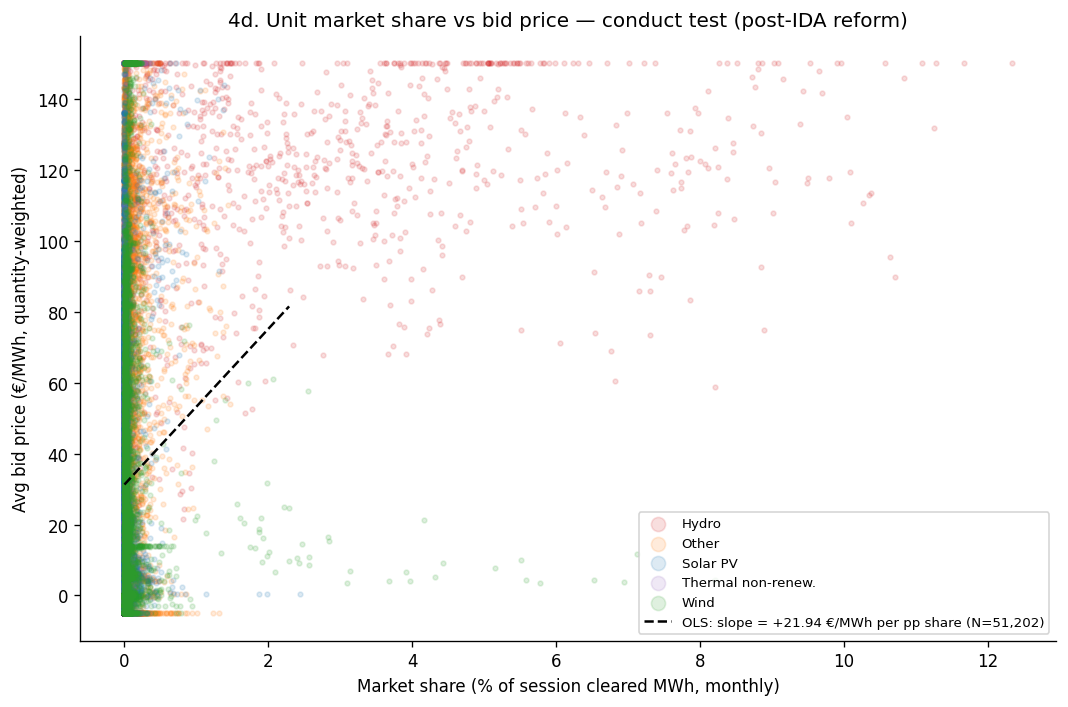

OLS: avg_bid = 31.27 + 21.9434 × market_share_pct
=> 1 pp higher share associated with +21.94 €/MWh bid premium


In [29]:
import numpy as np

IDA_REFORM_STR = IDA_REFORM.date().isoformat()

# Monthly unit × session: market share and quantity-weighted avg bid price
ms_bids = con.execute(f"""
    WITH offers AS (
        SELECT date::DATE AS date, session_number, offer_code, unit_code
        FROM read_parquet('{ICAB}')
        WHERE buy_sell = 'V'
          AND date::DATE >= '{IDA_REFORM_STR}'
          AND need_type NOT IN ('N 7', '70', '113',
                                'N 5', '50', '111',
                                'N 6', '61', 'N 8', '81', '90', '101', '102', '103', 'N 9')
    ),
    unit_stats AS (
        SELECT
            DATE_TRUNC('month', d.date::TIMESTAMP)::DATE              AS month,
            d.session_number,
            o.unit_code,
            SUM(d.quantity_mw * d.mtu_minutes / 60.0)                AS unit_mwh,
            SUM(d.price_eur_mwh * d.quantity_mw * d.mtu_minutes / 60.0)
              / NULLIF(SUM(d.quantity_mw * d.mtu_minutes / 60.0), 0) AS wavg_bid
        FROM read_parquet('{IDET}') d
        JOIN offers o
            ON  d.date::DATE     = o.date
            AND d.session_number = o.session_number
            AND d.offer_code     = o.offer_code
        WHERE d.date::DATE >= '{IDA_REFORM_STR}'
        GROUP BY 1, 2, o.unit_code
    ),
    market_total AS (
        SELECT month, session_number, SUM(unit_mwh) AS total_mwh
        FROM unit_stats GROUP BY month, session_number
    ),
    tech_lkp AS (
        SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
    )
    SELECT
        u.month, u.session_number, u.unit_code,
        tm.technology,
        u.unit_mwh / t.total_mwh * 100   AS market_share_pct,
        u.wavg_bid                        AS avg_bid_price
    FROM unit_stats u
    JOIN market_total t USING (month, session_number)
    LEFT JOIN tech_lkp tm ON tm.unit_code = u.unit_code
    WHERE u.unit_mwh > 0
""").df()

ms_bids["tech_group"] = ms_bids["technology"].map(TECH_MAP).fillna("Other")

# Colour by top-5 technology groups
top5_tg  = ms_bids["tech_group"].value_counts().head(5).index.tolist()
palette  = dict(zip(top5_tg, ["C0", "C1", "C2", "C3", "C4"]))

fig, ax = plt.subplots(figsize=(9, 6))
for tg, sub in ms_bids[ms_bids["tech_group"].isin(top5_tg)].groupby("tech_group"):
    ax.scatter(sub["market_share_pct"], sub["avg_bid_price"].clip(-5, 150),
               alpha=0.15, s=8, label=tg, color=palette[tg])

# OLS trend line across all technology groups
xy = ms_bids[["market_share_pct", "avg_bid_price"]].dropna()
xy = xy[(xy["avg_bid_price"] > -5) & (xy["avg_bid_price"] < 200)]
m, b = np.polyfit(xy["market_share_pct"], xy["avg_bid_price"], 1)
xs   = np.linspace(0, xy["market_share_pct"].quantile(0.99), 100)
ax.plot(xs, m * xs + b, "k--", linewidth=1.5,
        label=f"OLS: slope = {m:+.2f} €/MWh per pp share (N={len(xy):,})")

ax.set_xlabel("Market share (% of session cleared MWh, monthly)")
ax.set_ylabel("Avg bid price (€/MWh, quantity-weighted)")
ax.set_title("4d. Unit market share vs bid price — conduct test (post-IDA reform)")
ax.legend(fontsize=8, markerscale=3)
fig.tight_layout()
plt.show()

print(f"OLS: avg_bid = {b:.2f} + {m:.4f} × market_share_pct")
print(f"=> 1 pp higher share associated with {m:+.2f} €/MWh bid premium")

---
## Section 5 — Continuous intraday order book (XBID)

**Context.** Since June 2018, OMIE participants have access to the cross-border continuous intraday market (XBID), which operates as a **limit-order book** in parallel with the intraday auctions. Unlike the auction mechanism — which clears at a single uniform price — XBID matches buy and sell limit orders continuously at their agreed bilateral prices.

**Notation.** Let $\mathcal{O}_{tw}$ denote the set of orders submitted on trade date $t$ for delivery window $w$. Each order $o \in \mathcal{O}_{tw}$ is a tuple

$$o = \bigl(i_o,\ a_o,\ s_o,\ \bar{p}_o,\ \bar{q}_o,\ \kappa_o,\ \tau_o^{\text{sub}}\bigr)$$

where $i_o$ is the generating unit, $a_o$ the agent, $s_o \in \{V, C\}$ the side (sell/buy), $\bar{p}_o$ the limit price (€/MWh), $\bar{q}_o$ the offered quantity (MW), $\kappa_o$ the execution condition ($\varnothing$ = standard limit, ICE = iceberg, IOC = immediate-or-cancel), and $\tau_o^{\text{sub}}$ the submission timestamp.

**Delivery-window duration** switches at the MTU15 reform:

$$\delta_w = \begin{cases} 60\text{ min} & t < 2025\text{-}03\text{-}19 \\\\ 15\text{ min} & t \geq 2025\text{-}03\text{-}19 \end{cases}$$

The **MWh content** of order $o$ is $\bar{E}_o = \bar{q}_o \cdot \delta_w / 60$.

**Research questions:**
1. **5a — Market growth.** How has XBID activity evolved, and how did MTU15 change trading intensity?
2. **5b — Fragmentation.** Did the reform produce genuine finer-grained trading, or did energy content per window stay constant?
3. **5c — Submission timing.** When do agents submit relative to delivery, and did this shift post-reform?
4. **5d — Strategic order type.** How prevalent are iceberg orders ($\kappa_o = \text{ICE}$), and has their use grown over time?

In [30]:
INTRADAY_REFORM_STR = INTRADAY_REFORM.date().isoformat()   # 2025-03-19

### 5a. XBID order book growth over time

Monthly order count by side $s$:

$$N_m^{s} = \bigl|\{o \in \mathcal{O}_m : s_o = s\}\bigr|$$

and aggregate MWh offered (submitted, not necessarily matched):

$$Q_m^{s} = \sum_{o \in \mathcal{O}_m,\, s_o = s} \bar{q}_o \cdot \frac{\delta_{w(o)}}{60}$$

The MTU15 reform multiplied the number of distinct delivery windows per day by four (24 → 96), so a mechanical increase in $N_m$ is expected even without any behavioural change. $Q_m$ (MWh) controls for this effect.

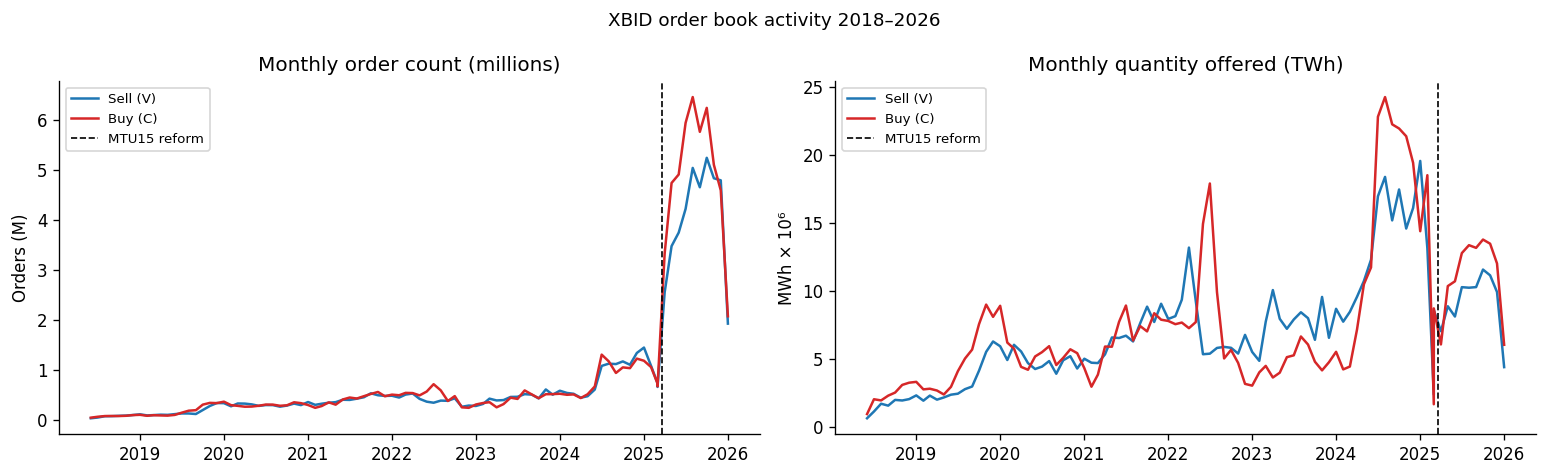

                           n_orders   total_mwh
month_dt                                       
Pre-MTU15 (monthly avg)    425118.0   6959936.0
Post-MTU15 (monthly avg)  4480758.0  10181197.0


In [31]:
orders_monthly = con.execute(f"""
    SELECT
        STRFTIME(trade_date::DATE, '%Y-%m')    AS month,
        mtu_minutes,
        offer_type                             AS side,
        COUNT(*)                               AS n_orders,
        SUM(quantity_mw * mtu_minutes / 60.0)  AS total_mwh
    FROM read_parquet('{ORDERS}')
    GROUP BY 1, 2, 3
    ORDER BY 1, 3
""").df()
orders_monthly["month_dt"] = pd.to_datetime(orders_monthly["month"] + "-01")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for side, color, label in [("V", "C0", "Sell (V)"), ("C", "C3", "Buy (C)")]:
    sub = orders_monthly[orders_monthly["side"] == side]
    axes[0].plot(sub["month_dt"], sub["n_orders"] / 1e6, color=color, label=label)
    axes[1].plot(sub["month_dt"], sub["total_mwh"]  / 1e6, color=color, label=label)

for ax in axes:
    ax.axvline(pd.Timestamp(INTRADAY_REFORM_STR), color="k", lw=1, ls="--", label="MTU15 reform")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)

axes[0].set(title="Monthly order count (millions)", ylabel="Orders (M)")
axes[1].set(title="Monthly quantity offered (TWh)", ylabel="MWh \u00d7 10\u2076")
fig.suptitle("XBID order book activity 2018\u20132026", fontsize=11)
plt.tight_layout(); plt.show()

summary_5a = (
    orders_monthly
    .groupby(orders_monthly["month_dt"] >= INTRADAY_REFORM)[["n_orders", "total_mwh"]]
    .mean()
    .rename(index={False: "Pre-MTU15 (monthly avg)", True: "Post-MTU15 (monthly avg)"})
)
print(summary_5a.round(0))

### 5b. MTU15 fragmentation: order size pre vs post reform

To separate the *intensive margin* (size per order) from the *extensive margin* (number of orders), compare the distribution of per-order MWh content $\bar{E}_o = \bar{q}_o \cdot \delta_w / 60$ across regimes.

Under **pure mechanical fragmentation** — agents simply split each 60-min order into four 15-min orders of equal energy — we would expect $\bar{E}_o$ to be *unchanged*. A statistically significant decline in $\bar{E}_o$ indicates *genuine* finer-grained trading in the post-reform market.

We quantify the difference using a **Welch 95% CI** on $\bar{E}^{\text{pre}} - \bar{E}^{\text{post}}$. The CI is computed from sufficient statistics (mean, variance, count), relying on the CLT at $n \approx 10^8$.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

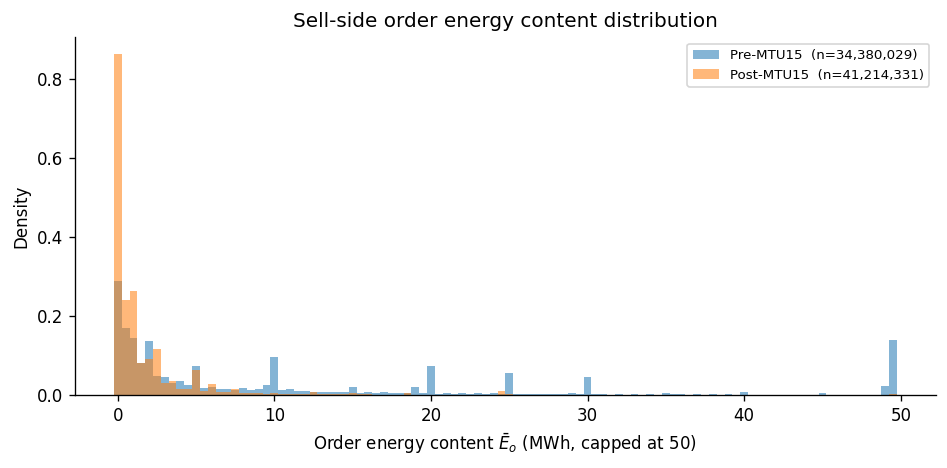

Sell-side order energy (MWh) summary by regime:
                   n  mean_mwh  median_mwh  std_mwh  p25_mwh  p75_mwh
regime                                                               
Pre-MTU15   34380029    16.362       4.800   37.438    1.000    19.00
Post-MTU15  41214331     2.287       0.675    5.757    0.225     2.35

Welch 95% CI on (mean_pre − mean_post): [14.0625, 14.0878] MWh


In [32]:
import numpy as np

# 5b-1: Summary stats per regime — DuckDB only, O(scan)
stats_5b = con.execute(f"""
    SELECT
        CASE WHEN mtu_minutes = 15 THEN 'Post-MTU15' ELSE 'Pre-MTU15' END AS regime,
        COUNT(*)                                            AS n,
        AVG(quantity_mw * mtu_minutes / 60.0)               AS mean_mwh,
        MEDIAN(quantity_mw * mtu_minutes / 60.0)            AS median_mwh,
        STDDEV(quantity_mw * mtu_minutes / 60.0)            AS std_mwh,
        PERCENTILE_CONT(0.25) WITHIN GROUP
            (ORDER BY quantity_mw * mtu_minutes / 60.0)     AS p25_mwh,
        PERCENTILE_CONT(0.75) WITHIN GROUP
            (ORDER BY quantity_mw * mtu_minutes / 60.0)     AS p75_mwh
    FROM read_parquet('{ORDERS}')
    WHERE offer_type = 'V' AND quantity_mw > 0
    GROUP BY 1
""").df().set_index("regime")

# 5b-2: Histogram buckets (0–50 MWh, 0.5 MWh bins) — DuckDB
hist_5b = con.execute(f"""
    SELECT
        CASE WHEN mtu_minutes = 15 THEN 'Post-MTU15' ELSE 'Pre-MTU15' END AS regime,
        FLOOR(LEAST(quantity_mw * mtu_minutes / 60.0, 49.99) / 0.5) * 0.5 AS bucket,
        COUNT(*) AS n
    FROM read_parquet('{ORDERS}')
    WHERE offer_type = 'V' AND quantity_mw > 0
    GROUP BY 1, 2
""").df()

# Welch 95% CI from CLT (exact at n ~ 10^8)
pre  = stats_5b.loc['Pre-MTU15']
post = stats_5b.loc['Post-MTU15']
diff = pre['mean_mwh'] - post['mean_mwh']
se   = np.sqrt(pre['std_mwh']**2 / pre['n'] + post['std_mwh']**2 / post['n'])
ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se

fig, ax = plt.subplots(figsize=(8, 4))
for regime, color in [("Pre-MTU15", "C0"), ("Post-MTU15", "C1")]:
    sub = hist_5b[hist_5b["regime"] == regime].sort_values("bucket")
    totals = sub["n"].sum()
    ax.bar(sub["bucket"], sub["n"] / totals / 0.5,
           width=0.5, alpha=0.55, color=color,
           label=f"{regime}  (n={int(stats_5b.loc[regime, 'n']):,})")

ax.set(xlabel="Order energy content $\\bar{E}_o$ (MWh, capped at 50)",
       ylabel="Density",
       title="Sell-side order energy content distribution")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Sell-side order energy (MWh) summary by regime:")
print(stats_5b[["n","mean_mwh","median_mwh","std_mwh","p25_mwh","p75_mwh"]].round(3))
print(f"\nWelch 95% CI on (mean_pre − mean_post): [{ci_lo:.4f}, {ci_hi:.4f}] MWh")

### 5c. Order submission lead time

Define the **lead time** of order $o$:

$$\ell_o = \tau_o^{\text{delivery}} - \tau_o^{\text{sub}} \quad [\text{hours}]$$

The XBID gate opens roughly 30 hours before delivery (when the day-ahead clearing result is published) and closes 30 min before delivery. Strategic models of learning predict that better-informed agents trade closer to real time, as within-day price signals (renewable forecast updates, demand deviations) improve. If the MTU15 reform sharpened within-hour price signals, agents should shift their order flow toward shorter lead times post-reform.

We measure the empirical distribution of $\ell_o$ in the two regimes and report the share of orders placed within 2 hours of delivery — a proxy for *near-real-time* trading.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

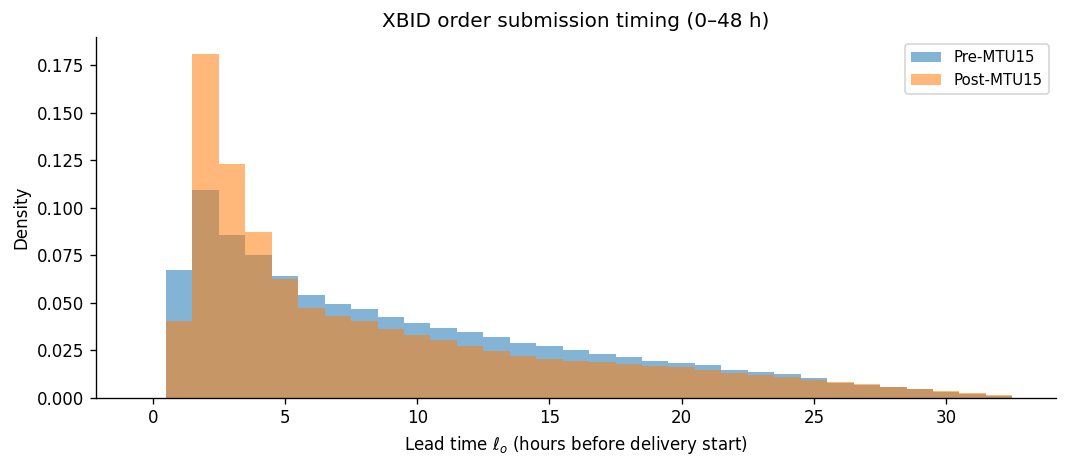

Lead time summary (hours):
            mean_lead_h  median_lead_h  share_within_2h
regime                                                 
Pre-MTU15         9.335          7.370            0.140
Post-MTU15        8.463          5.618            0.133


In [33]:
# 5c-1: Lead-time histogram buckets — DuckDB, no large DataFrame in Python
lead_hist = con.execute(f"""
    SELECT
        CASE WHEN mtu_minutes = 15 THEN 'Post-MTU15' ELSE 'Pre-MTU15' END AS regime,
        ROUND(
            EPOCH(
                strptime(delivery_start, '%Y-%m-%d %H:%M')
                - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
            ) / 3600.0
        )::INTEGER AS lead_h,
        COUNT(*) AS n
    FROM read_parquet('{ORDERS}')
    WHERE LENGTH(submitted_at) = 19
      AND EPOCH(
            strptime(delivery_start, '%Y-%m-%d %H:%M')
            - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
          ) BETWEEN 0 AND 48 * 3600
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

# 5c-2: Summary stats in DuckDB
lead_stats = con.execute(f"""
    SELECT
        CASE WHEN mtu_minutes = 15 THEN 'Post-MTU15' ELSE 'Pre-MTU15' END AS regime,
        AVG(EPOCH(
            strptime(delivery_start, '%Y-%m-%d %H:%M')
            - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
        ) / 3600.0) AS mean_lead_h,
        MEDIAN(EPOCH(
            strptime(delivery_start, '%Y-%m-%d %H:%M')
            - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
        ) / 3600.0) AS median_lead_h,
        AVG(CASE WHEN EPOCH(
            strptime(delivery_start, '%Y-%m-%d %H:%M')
            - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
        ) < 2 * 3600 THEN 1.0 ELSE 0.0 END) AS share_within_2h
    FROM read_parquet('{ORDERS}')
    WHERE LENGTH(submitted_at) = 19
      AND EPOCH(
            strptime(delivery_start, '%Y-%m-%d %H:%M')
            - strptime(submitted_at,  '%d/%m/%Y %H:%M:%S')
          ) BETWEEN 0 AND 72 * 3600
    GROUP BY 1
""").df().set_index("regime")

fig, ax = plt.subplots(figsize=(9, 4))
for regime, color in [("Pre-MTU15", "C0"), ("Post-MTU15", "C1")]:
    sub = lead_hist[lead_hist["regime"] == regime].sort_values("lead_h")
    totals = sub["n"].sum()
    ax.bar(sub["lead_h"], sub["n"] / totals, width=1.0,
           alpha=0.55, color=color, label=regime)

ax.set(xlabel="Lead time $\\ell_o$ (hours before delivery start)",
       ylabel="Density",
       title="XBID order submission timing (0\u201348 h)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Lead time summary (hours):")
print(lead_stats.round(3))

### 5d. Iceberg order prevalence

An **iceberg order** ($\kappa_o = \text{ICE}$) hides part of its quantity from the public order book, revealing only a visible *peak* while the remaining *hidden* quantity waits to be matched. Iceberg orders are a standard tool for large participants wishing to avoid **price impact** — a classic example of *strategic information concealment* in limit-order markets.

Define the monthly iceberg share:

$$\phi_m^{\text{ICE}} = \frac{|\{o \in \mathcal{O}_m : \kappa_o = \text{ICE}\}|}{|\mathcal{O}_m|}$$

A secular rise in $\phi_m^{\text{ICE}}$ is consistent with (i) growing average order size (more incentive to hide), (ii) deeper liquidity enabling hidden quantities to fill, or (iii) a strategic response to the increased price-signal transparency brought by the MTU15 reform.

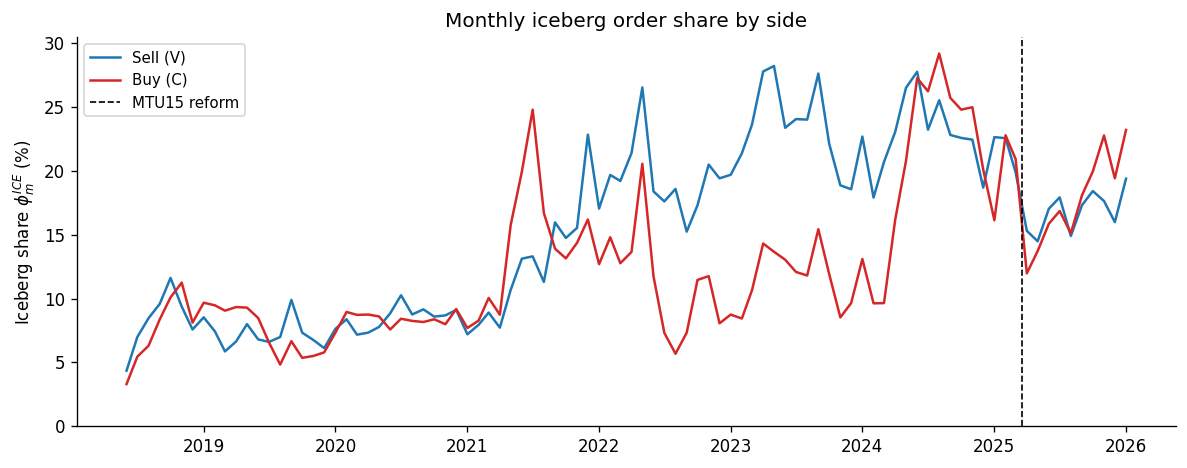

Mean iceberg share pre/post MTU15 reform:
side            C      V
post                    
Pre-MTU15   12.2%  15.2%
Post-MTU15  17.7%  16.8%


In [34]:
ice_monthly = con.execute(f"""
    SELECT
        STRFTIME(trade_date::DATE, '%Y-%m') AS month,
        offer_type                          AS side,
        AVG(CASE WHEN exec_condition = 'ICE' THEN 1.0 ELSE 0.0 END) AS ice_share,
        COUNT(*)                            AS n_orders
    FROM read_parquet('{ORDERS}')
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()
ice_monthly["month_dt"] = pd.to_datetime(ice_monthly["month"] + "-01")

fig, ax = plt.subplots(figsize=(10, 4))
for side, color, label in [("V", "C0", "Sell (V)"), ("C", "C3", "Buy (C)")]:
    sub = ice_monthly[ice_monthly["side"] == side]
    ax.plot(sub["month_dt"], sub["ice_share"] * 100, color=color, label=label)

ax.axvline(pd.Timestamp(INTRADAY_REFORM_STR), color="k", lw=1, ls="--", label="MTU15 reform")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set(ylabel="Iceberg share $\\phi_m^{ICE}$ (%)",
       title="Monthly iceberg order share by side",
       ylim=(0, None))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Mean iceberg share pre/post MTU15 reform:")
ice_monthly["post"] = ice_monthly["month_dt"] >= INTRADAY_REFORM
print(
    ice_monthly.groupby(["post", "side"])["ice_share"]
    .mean().unstack()
    .rename(index={False: "Pre-MTU15", True: "Post-MTU15"})
    .map(lambda x: f"{100*x:.1f}%")
)